In [232]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        pass

In [233]:
%pip install -q pandas matplotlib seaborn numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.


In [234]:
import warnings
warnings.filterwarnings("ignore")

In [235]:
df = pd.read_csv("/kaggle/input/datasets/andradaolteanu/kaggle-data-science-survey-20172021/kaggle_survey_2017_2021.csv", low_memory=False, header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,283,284,285,286,287,288,289,290,291,292
0,-,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,...,Q38_B_Part_1,Q38_B_Part_2,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_9,Q38_B_Part_11,Q38_B_OTHER
1,Year,Duration (in seconds),What is your age (# years)?,What is your gender? - Selected Choice,In which country do you currently reside?,What is the highest level of formal education ...,Select the title most similar to your current ...,For how many years have you been writing code ...,What programming languages do you use on a reg...,What programming languages do you use on a reg...,...,"In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor..."
2,2021,910,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,784,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021,924,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,Python,NaN,...,NaN,NaN,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,NaN


In [236]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106303 entries, 0 to 106302
Columns: 293 entries, 0 to 292
dtypes: object(293)
memory usage: 237.6+ MB


In [237]:
df.columns = (df.iloc[0] + '_' + df.iloc[1])
df.drop([0,1],inplace=True)
df.head()

,-_Year,Time from Start to Finish (seconds)_Duration (in seconds),Q1_What is your age (# years)?,Q2_What is your gender? - Selected Choice,Q3_In which country do you currently reside?,Q4_What is the highest level of formal education that you have attained or plan to attain within the next 2 years?,Q5_Select the title most similar to your current role (or most recent title if retired): - Selected Choice,Q6_For how many years have you been writing code and/or programming?,Q7_Part_1_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Python,Q7_Part_2_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - R,...,"Q38_B_Part_1_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Neptune.ai","Q38_B_Part_2_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Weights & Biases","Q38_B_Part_3_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Comet.ml","Q38_B_Part_4_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Sacred + Omniboard","Q38_B_Part_5_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - TensorBoard","Q38_B_Part_6_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Guild.ai","Q38_B_Part_7_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Polyaxon","Q38_B_Part_9_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Domino Model Monitor","Q38_B_Part_11_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - None","Q38_B_OTHER_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Other"
2,2021,910,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,784,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021,924,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,Python,NaN,...,NaN,NaN,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,NaN
5,2021,575,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2021,781,45-49,Man,India,Doctoral degree,Other,< 1 years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [238]:
df.isnull().sum()

-_Year                                                                                                                                                                                                0
Time from Start to Finish (seconds)_Duration (in seconds)                                                                                                                                         16716
Q1_What is your age (# years)?                                                                                                                                                                      445
Q2_What is your gender? - Selected Choice                                                                                                                                                            95
Q3_In which country do you currently reside?                                                                                                                                                        121


In [239]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct.head(10)

Q38_B_Part_11_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - None                                                             100.0
Q34_B_Part_16_Which of the following business intelligence tools do you hope to become more familiar with in the next 2 years? (Select all that apply) - Selected Choice - None                                                          100.0
Q9_Part_12_Which of the following integrated development environments (IDE's) do you use on a regular basis?  (Select all that apply) - Selected Choice - None                                                                           100.0
Q7_Part_12_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - None                                                                                                                    100.0
Q14_Part_11_What data visualization librarie

In [240]:
df.dtypes

-_Year                                                                                                                                                                                           object
Time from Start to Finish (seconds)_Duration (in seconds)                                                                                                                                        object
Q1_What is your age (# years)?                                                                                                                                                                   object
Q2_What is your gender? - Selected Choice                                                                                                                                                        object
Q3_In which country do you currently reside?                                                                                                                                                     object


In [241]:
df.loc[1:, '-_Year'].unique()

array(['2021', '2020', '2019', '2018', '2017'], dtype=object)

In [242]:
df['-_Year'] = df['-_Year'].astype('int64')
df.loc[1:, '-_Year'].unique()

array([2021, 2020, 2019, 2018, 2017])

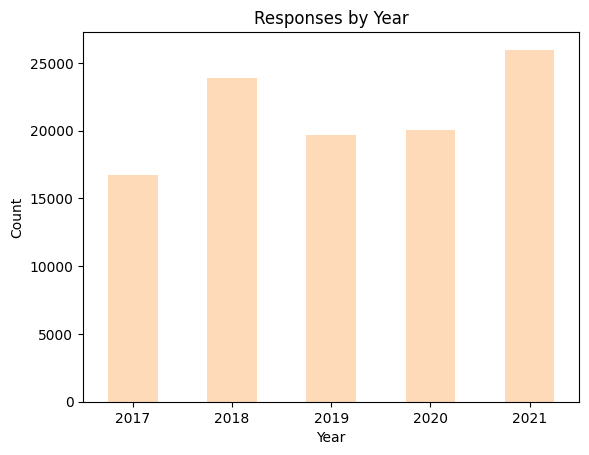

In [243]:
import matplotlib.pyplot as plt

year_count = df.loc[1:, '-_Year'].value_counts()
year_count = year_count.sort_index()

year_count.plot(kind='bar', color='peachpuff')

plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Responses by Year')
plt.xticks(rotation=0)

plt.show()

In [244]:
df['Time from Start to Finish (seconds)_Duration (in seconds)'] = df['Time from Start to Finish (seconds)_Duration (in seconds)'].fillna(0)
df['Time from Start to Finish (seconds)_Duration (in seconds)'] = df['Time from Start to Finish (seconds)_Duration (in seconds)'].astype('int64')
df['Time from Start to Finish (seconds)_Duration (in seconds)'].dtype

dtype('int64')

In [245]:
# Check the unique data in age group
df.iloc[1: , 2].unique()

array(['50-54', '22-24', '45-49', '25-29', '18-21', '30-34', '40-44',
       '35-39', '70+', '55-59', '60-69', nan], dtype=object)

In [246]:
df.shape

(106301, 293)

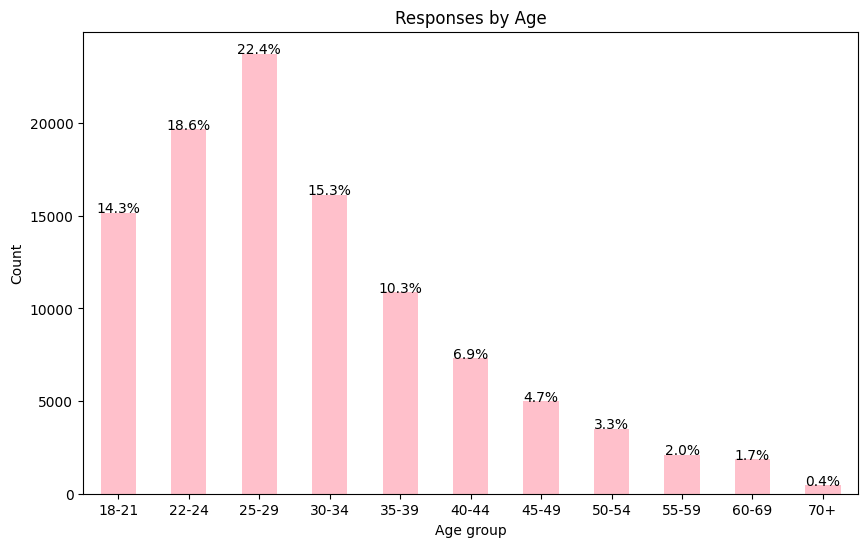

In [247]:

plt.figure(figsize=(10, 6)) 

age_count = df.iloc[1:, 2].value_counts()
age_count = age_count.sort_index()

ax = age_count.plot(kind='bar', color='pink')

percentage = age_count / age_count.sum() * 100

ax.set_xticklabels(age_count.index, rotation=0)
ax.set_xlabel('Age group')
ax.set_ylabel('Count')
ax.set_title('Responses by Age')

for i, (count, pct) in enumerate(zip(age_count, percentage)):
    ax.text(i, count + 1, f"{pct:.1f}%", ha='center')

plt.show()

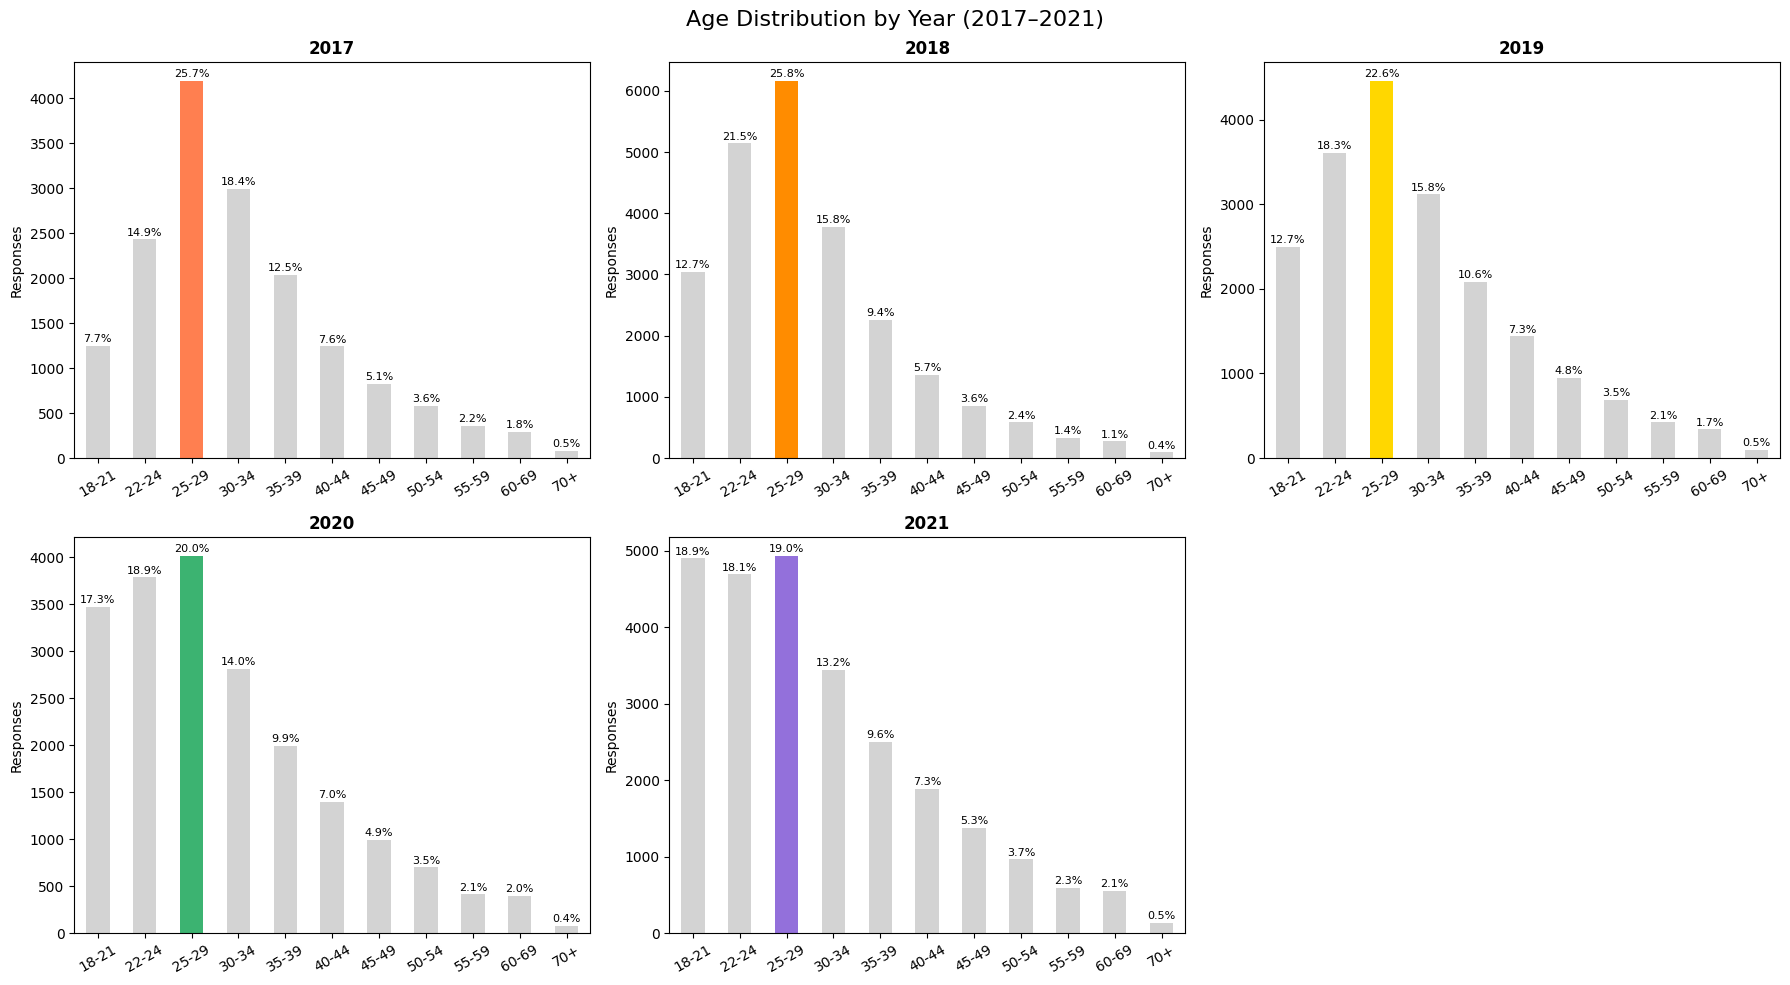

In [249]:
import matplotlib.pyplot as plt

years = sorted(df['-_Year'].dropna().unique())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

highlight_colors = [
    'coral',
    'darkorange',
    'gold',
    'mediumseagreen',
    'mediumpurple'
]

for ax, year, highlight in zip(axes, years, highlight_colors):

    age_count = (
        df[df['-_Year'] == year]
        .iloc[:, 2]
        .value_counts()
        .sort_index()
    )

    percentage = age_count / age_count.sum() * 100

    # Make all bars light gray
    colors = ['lightgray'] * len(age_count)

    # Highlight the age group with the highest responses
    colors[age_count.argmax()] = highlight

    age_count.plot(
        kind='bar',
        ax=ax,
        color=colors
    )

    for i, (count, pct) in enumerate(zip(age_count, percentage)):
        ax.text(
            i,
            count + age_count.max()*0.01,
            f'{pct:.1f}%',
            ha='center',
            fontsize=8
        )

    ax.set_title(f'{year}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Responses')
    ax.tick_params(axis='x', rotation=30)

# Remove the unused subplot
fig.delaxes(axes[-1])

plt.suptitle('Age Distribution by Year (2017–2021)', fontsize=16)
plt.tight_layout()
plt.show()

## Gender workflow over time

In [250]:
df.iloc[1:, 3].unique()

array(['Man', 'Woman', 'Nonbinary', 'Prefer not to say',
       'Prefer to self-describe', 'Male', 'Female',
       'Non-binary, genderqueer, or gender non-conforming',
       'A different identity', nan], dtype=object)

In [251]:
df.iloc[1: , 3] = df.iloc[1:,3].replace({'Man':'Male', 'Woman':'Female'})
df.iloc[1:, 3].unique()

array(['Male', 'Female', 'Nonbinary', 'Prefer not to say',
       'Prefer to self-describe',
       'Non-binary, genderqueer, or gender non-conforming',
       'A different identity', nan], dtype=object)

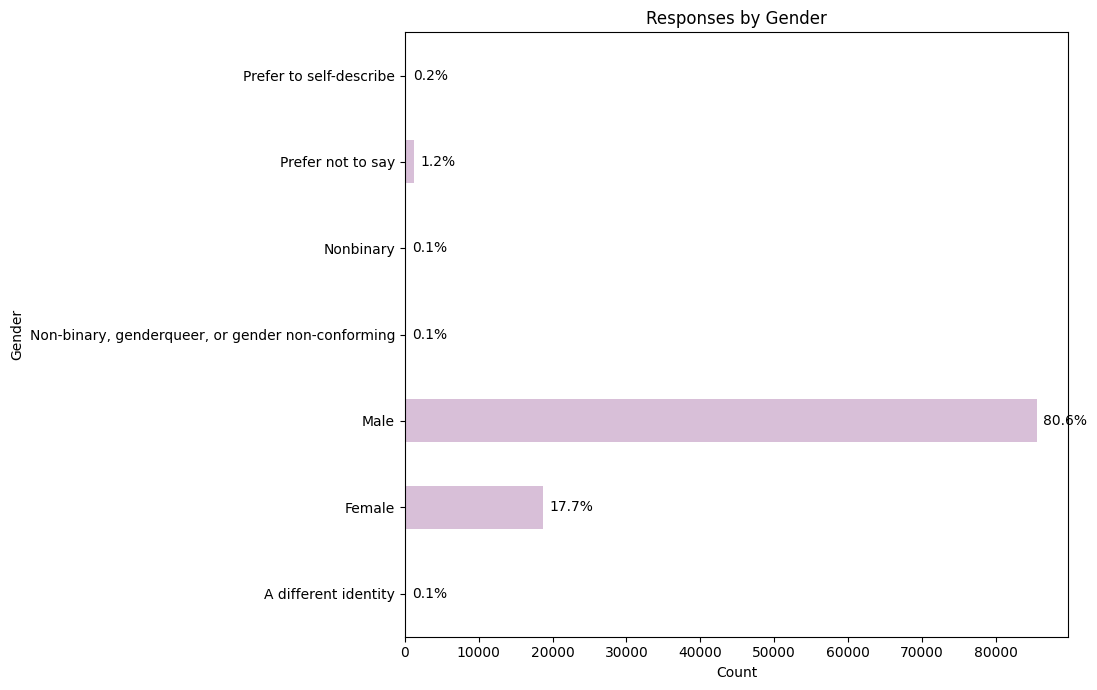

In [252]:
plt.figure(figsize=(11, 7))

# Create gender_count first
gender_count = (
    df.iloc[1:, 3]
    .value_counts()
    .sort_index()
)

percentage = gender_count / gender_count.sum() * 100

ax = gender_count.plot(kind='barh', color='thistle')

ax.set_xlabel('Count')
ax.set_ylabel('Gender')
ax.set_title('Responses by Gender')

for i, (count, pct) in enumerate(zip(gender_count, percentage)):
    ax.text(
        count + gender_count.max()*0.01,
        i,
        f'{pct:.1f}%',
        va='center'
    )

plt.tight_layout()
plt.show()

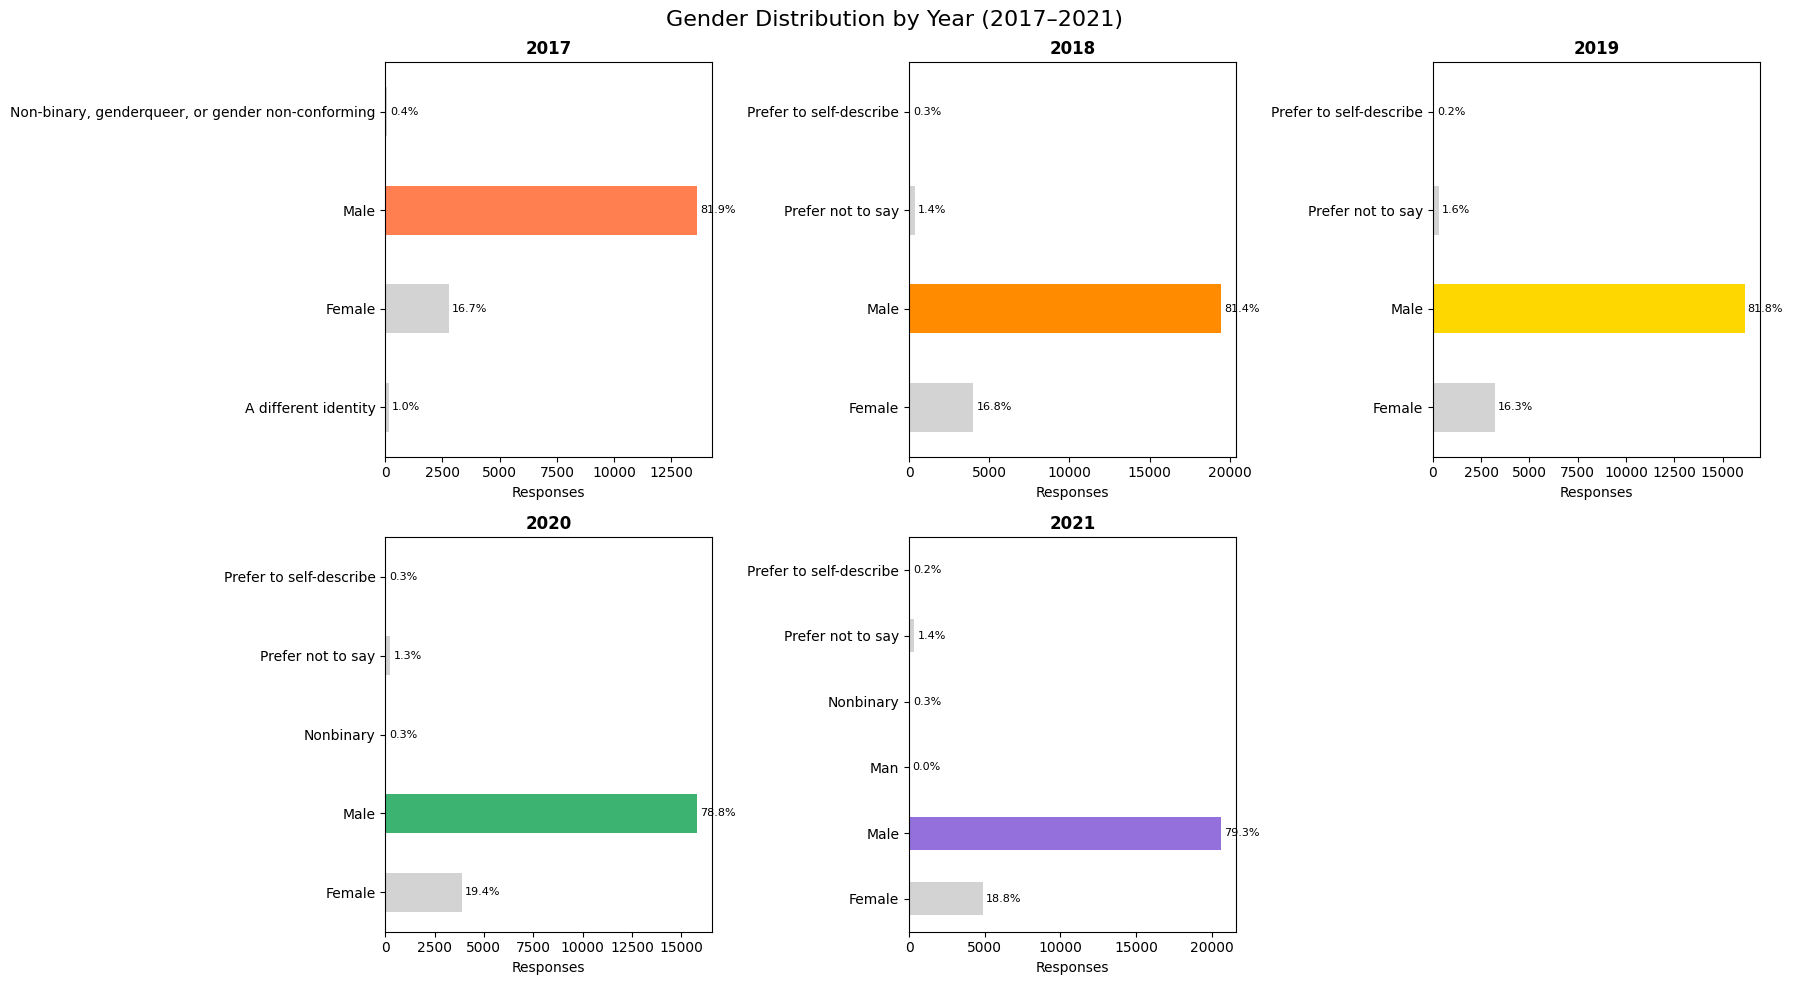

In [253]:


years = sorted(df['-_Year'].dropna().unique())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

highlight_colors = [
    'coral',
    'darkorange',
    'gold',
    'mediumseagreen',
    'mediumpurple'
]

for ax, year, highlight in zip(axes, years, highlight_colors):

    gender_count = (
        df[df['-_Year'] == year]
        .iloc[:, 3]
        .value_counts()
        .sort_index()
    )

    percentage = gender_count / gender_count.sum() * 100

    # Light gray for all bars
    colors = ['lightgray'] * len(gender_count)

    # Highlight the largest category
    colors[gender_count.argmax()] = highlight

    gender_count.plot(
        kind='barh',
        ax=ax,
        color=colors
    )

    # Add percentage labels
    for i, (count, pct) in enumerate(zip(gender_count, percentage)):
        ax.text(
            count + gender_count.max() * 0.01,
            i,
            f'{pct:.1f}%',
            va='center',
            fontsize=8
        )

    ax.set_title(f'{year}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Responses')
    ax.set_ylabel('')

# Remove the unused subplot
fig.delaxes(axes[-1])

plt.suptitle('Gender Distribution by Year (2017–2021)', fontsize=16)
plt.tight_layout()
plt.show()

## Country Responses over time

In [254]:
sorted(df.iloc[1:, 4].dropna().unique())

['Algeria',
 'Argentina',
 'Australia',
 'Austria',
 'Bangladesh',
 'Belarus',
 'Belgium',
 'Brazil',
 'Canada',
 'Chile',
 'China',
 'Colombia',
 'Czech Republic',
 'Denmark',
 'Ecuador',
 'Egypt',
 'Ethiopia',
 'Finland',
 'France',
 'Germany',
 'Ghana',
 'Greece',
 'Hong Kong',
 'Hong Kong (S.A.R.)',
 'Hungary',
 'I do not wish to disclose my location',
 'India',
 'Indonesia',
 'Iran',
 'Iran, Islamic Republic of...',
 'Iraq',
 'Ireland',
 'Israel',
 'Italy',
 'Japan',
 'Kazakhstan',
 'Kenya',
 'Malaysia',
 'Mexico',
 'Morocco',
 'Nepal',
 'Netherlands',
 'New Zealand',
 'Nigeria',
 'Norway',
 'Other',
 'Pakistan',
 "People 's Republic of China",
 'Peru',
 'Philippines',
 'Poland',
 'Portugal',
 'Republic of China',
 'Republic of Korea',
 'Romania',
 'Russia',
 'Saudi Arabia',
 'Singapore',
 'South Africa',
 'South Korea',
 'Spain',
 'Sri Lanka',
 'Sweden',
 'Switzerland',
 'Taiwan',
 'Thailand',
 'Tunisia',
 'Turkey',
 'Uganda',
 'Ukraine',
 'United Arab Emirates',
 'United Kingdom

In [255]:
# replaced countries that might affect the result of the top 3-5 countries
df.iloc[1:, 4] = df.iloc[1:, 4].replace({'Hong Kong (S.A.R.)': 'Hong Kong', 
                                         'Republic of China': 'Taiwan', 
                                         'Viet Nam': 'Vietnam', 
                                         'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom', 
                                         'United States of America': 'United States',
                                         'Iran, Islamic Republic of...': 'Iran',
                                         "People 's Republic of China": 'China'})
sorted(df.iloc[1:, 4].dropna().unique())

['Algeria',
 'Argentina',
 'Australia',
 'Austria',
 'Bangladesh',
 'Belarus',
 'Belgium',
 'Brazil',
 'Canada',
 'Chile',
 'China',
 'Colombia',
 'Czech Republic',
 'Denmark',
 'Ecuador',
 'Egypt',
 'Ethiopia',
 'Finland',
 'France',
 'Germany',
 'Ghana',
 'Greece',
 'Hong Kong',
 'Hungary',
 'I do not wish to disclose my location',
 'India',
 'Indonesia',
 'Iran',
 'Iraq',
 'Ireland',
 'Israel',
 'Italy',
 'Japan',
 'Kazakhstan',
 'Kenya',
 'Malaysia',
 'Mexico',
 'Morocco',
 'Nepal',
 'Netherlands',
 'New Zealand',
 'Nigeria',
 'Norway',
 'Other',
 'Pakistan',
 'Peru',
 'Philippines',
 'Poland',
 'Portugal',
 'Republic of Korea',
 'Romania',
 'Russia',
 'Saudi Arabia',
 'Singapore',
 'South Africa',
 'South Korea',
 'Spain',
 'Sri Lanka',
 'Sweden',
 'Switzerland',
 'Taiwan',
 'Thailand',
 'Tunisia',
 'Turkey',
 'Uganda',
 'Ukraine',
 'United Arab Emirates',
 'United Kingdom',
 'United States',
 'Vietnam']

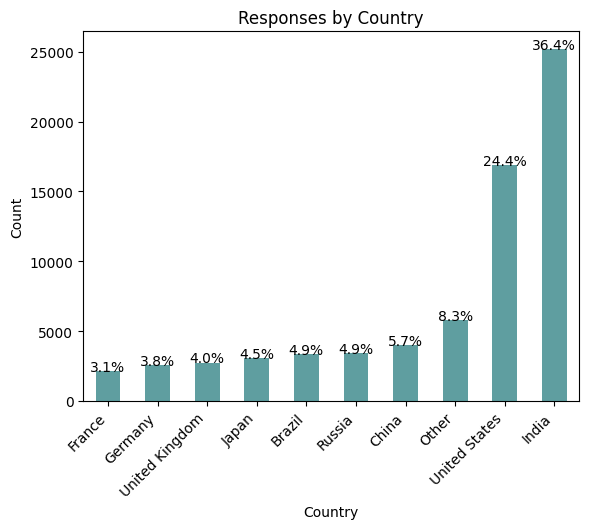

In [256]:
# visualise responses by country
country_count = df.iloc[1:, 4].value_counts().sort_values(ascending=False)[:10]
country_count = country_count.sort_values()
percentage = country_count / country_count.sum() * 100  # calculate percentage
ax = country_count.plot(kind='bar', color='cadetblue')
ax.set_xticklabels(country_count.index, rotation=45, ha='right')
ax.set_xlabel('Country')
ax.set_ylabel('Count')
ax.set_title('Responses by Country')
for i, v in enumerate(country_count):
    ax.text(i, v + 1, f"{percentage[i]:.1f}%", ha='center')  # plot percentage above each bar
plt.show()

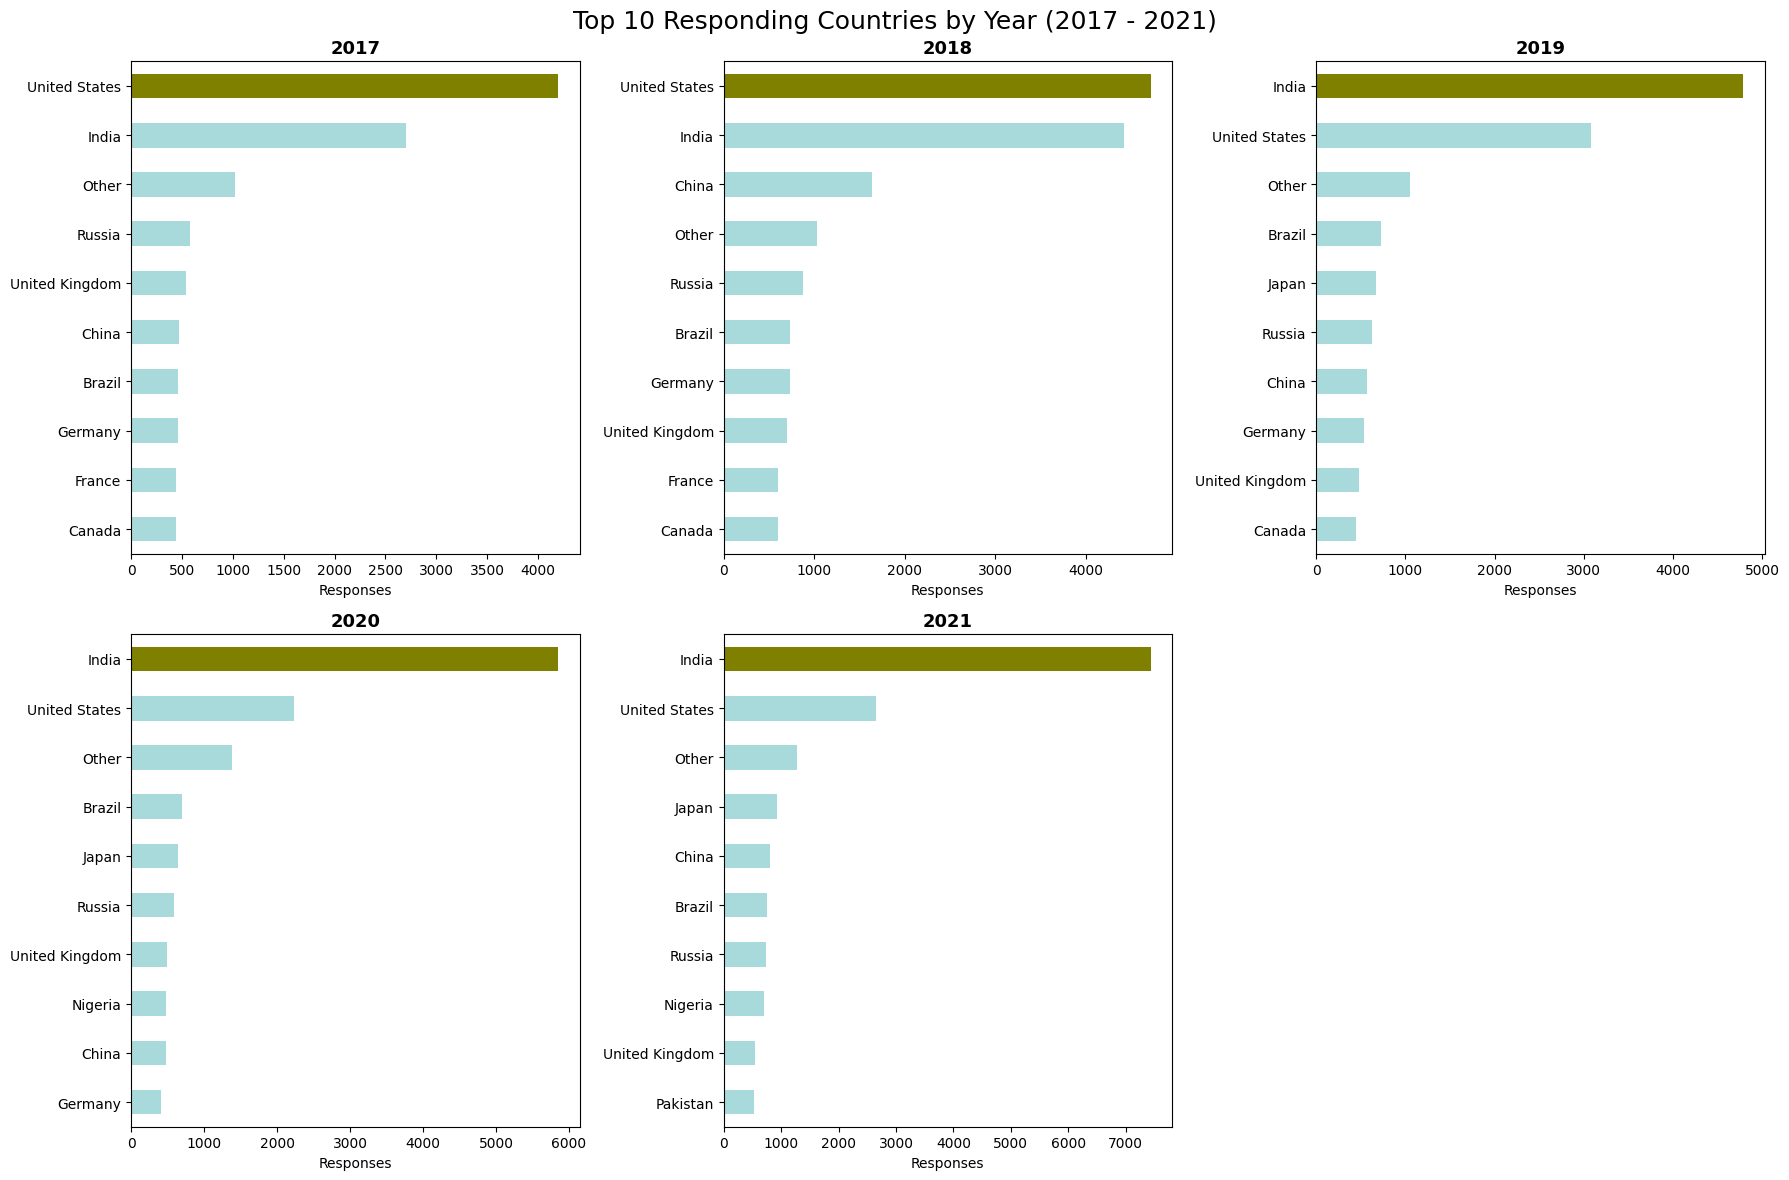

In [88]:
import matplotlib.pyplot as plt

years = sorted(df['-_Year'].dropna().unique())

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, year in zip(axes, years):
    country_count = (
        df[df['-_Year'] == year]
        .iloc[:, 4]
        .value_counts()
        .head(10)
        .sort_values()
    )

    colors = ['#A8DADC'] * len(country_count)
    colors[-1] = 'olive' 

    country_count.plot(
        kind='barh',
        color=colors,
        ax=ax
    )

    ax.set_title(f'{year}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Responses')
    ax.set_ylabel('')

# --- FIX: Hide any remaining empty subplots ---
for i in range(len(years), len(axes)):
    fig.delaxes(axes[i]) # This completely removes the unused subplot

plt.suptitle('Top 10 Responding Countries by Year (2017 - 2021)', fontsize=18)
plt.tight_layout()
plt.show()

## Trend in Employment over time

In [258]:
df.head()

,-_Year,Time from Start to Finish (seconds)_Duration (in seconds),Q1_What is your age (# years)?,Q2_What is your gender? - Selected Choice,Q3_In which country do you currently reside?,Q4_What is the highest level of formal education that you have attained or plan to attain within the next 2 years?,Q5_Select the title most similar to your current role (or most recent title if retired): - Selected Choice,Q6_For how many years have you been writing code and/or programming?,Q7_Part_1_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Python,Q7_Part_2_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - R,...,"Q38_B_Part_1_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Neptune.ai","Q38_B_Part_2_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Weights & Biases","Q38_B_Part_3_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Comet.ml","Q38_B_Part_4_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Sacred + Omniboard","Q38_B_Part_5_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - TensorBoard","Q38_B_Part_6_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Guild.ai","Q38_B_Part_7_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Polyaxon","Q38_B_Part_9_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Domino Model Monitor","Q38_B_Part_11_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - None","Q38_B_OTHER_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Other"
2,2021,910,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,784,50-54,Male,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021,924,22-24,Male,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,Python,NaN,...,NaN,NaN,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,NaN
5,2021,575,45-49,Male,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2021,781,45-49,Male,India,Doctoral degree,Other,< 1 years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [259]:
df.iloc[1:,5].unique()

array(['Masterâ€™s degree', 'Doctoral degree', 'I prefer not to answer',
       'Some college/university study without earning a bachelorâ€™s degree',
       'Bachelorâ€™s degree', 'No formal education past high school',
       'Professional doctorate', 'Professional degree', nan,
       "Bachelor's degree", "Master's degree",
       "Some college/university study without earning a bachelor's degree",
       'I did not complete any formal education past high school'],
      dtype=object)

In [260]:
# Clean education categories
df.iloc[1:, 5] = df.iloc[1:, 5].replace({
    # Fix encoding issues
    "Bachelorâ€™s degree": "Bachelor's degree",
    "Masterâ€™s degree": "Master's degree",

    # Merge college/university responses
    "Some college/university study without earning a bachelor's degree": "College/university",
    "Some college/university study without earning a bachelorâ€™s degree": "College/university",

    # Merge high school responses
    "I did not complete any formal education past high school": "Up to High School",
    "No formal education past high school": "Up to High School",
    # Merge doctorate categories 
    "Professional doctorate": "Doctoral degree",
    

    # Treat "Prefer not to answer" as missing (optional)
    "I prefer not to answer": np.nan
})

# Check the cleaned categories
sorted(df.iloc[1:, 5].dropna().unique())

["Bachelor's degree",
 'College/university',
 'Doctoral degree',
 "Master's degree",
 'Professional degree',
 'Up to High School']

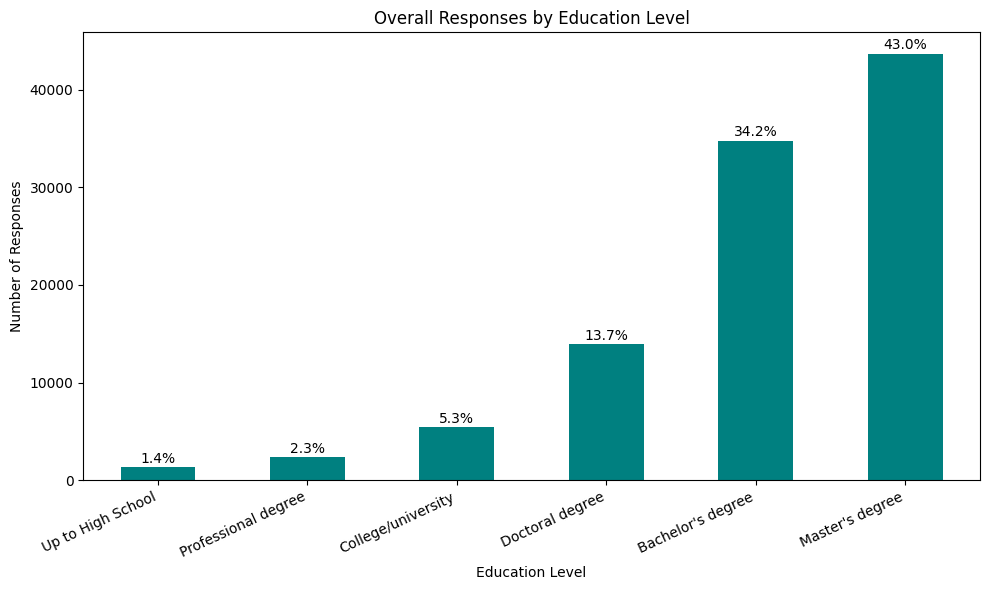

In [261]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

education_count = (
    df.iloc[1:, 5]
    .value_counts()
    .sort_values()
)

percentage = education_count / education_count.sum() * 100

ax = education_count.plot(
    kind='bar',
    color='teal'
)

ax.set_xlabel('Education Level')
ax.set_ylabel('Number of Responses')
ax.set_title('Overall Responses by Education Level')

plt.xticks(rotation=25, ha='right')

# Add percentage labels
for i, (count, pct) in enumerate(zip(education_count, percentage)):
    ax.text(i, count + education_count.max()*0.01,
            f'{pct:.1f}%',
            ha='center',
            fontsize=10)

plt.tight_layout()
plt.show()

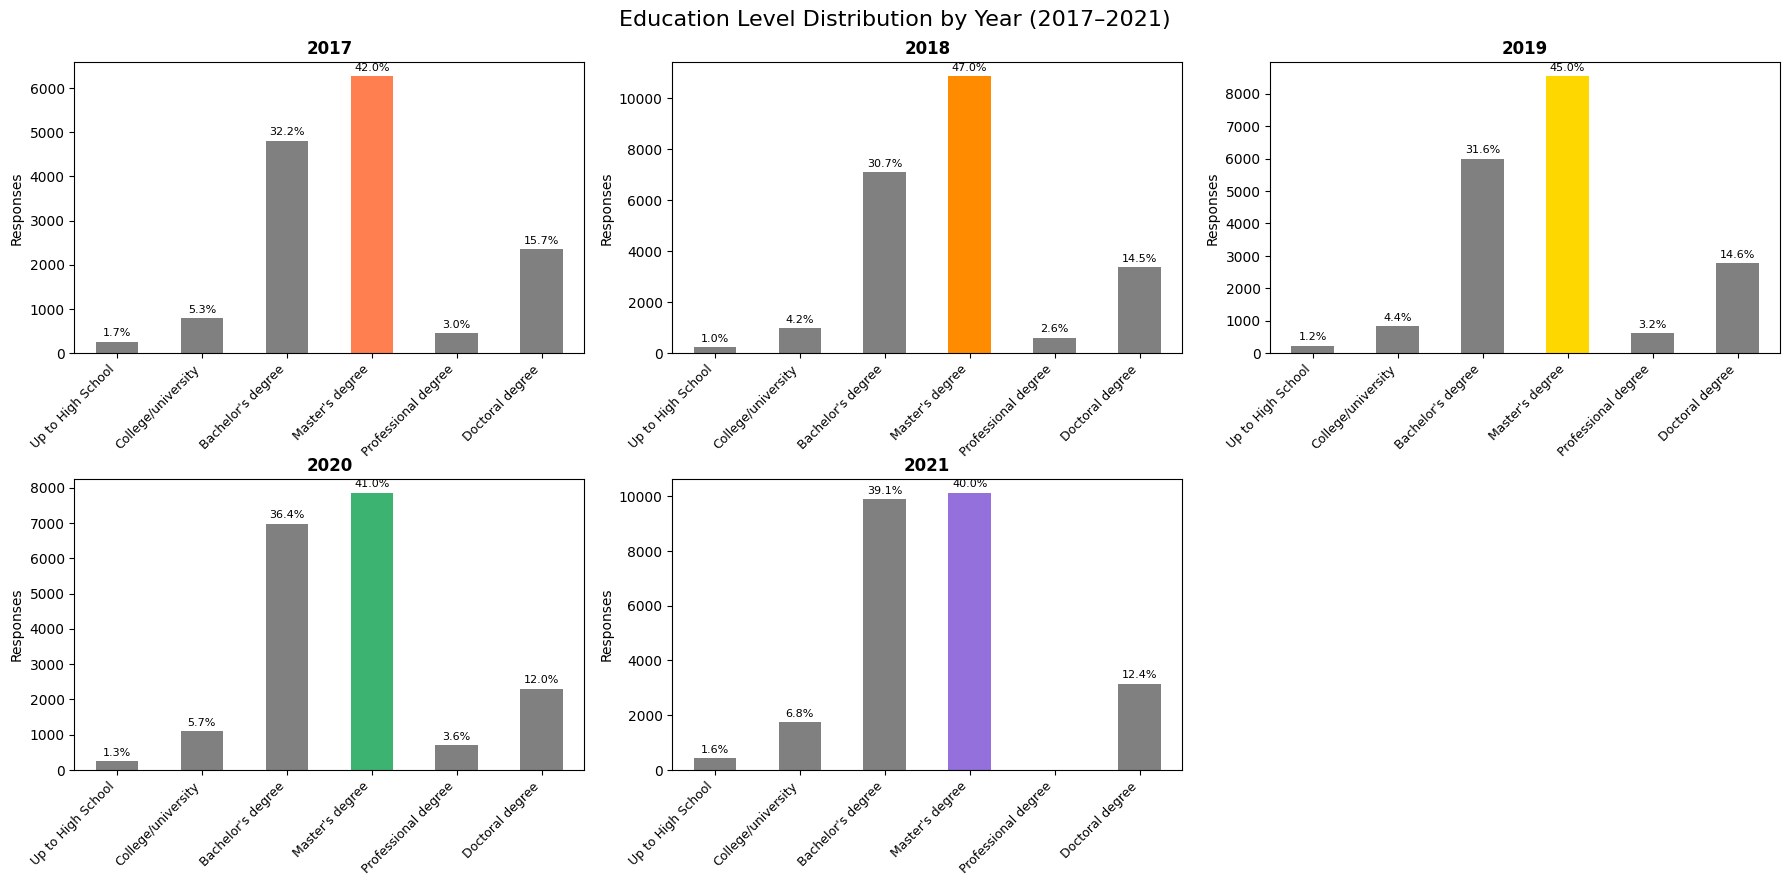

In [264]:
education_order = [
    'Up to High School',
    'College/university',
    "Bachelor's degree",
    "Master's degree",
    'Professional degree',
    'Doctoral degree'
]

years = sorted(df['-_Year'].dropna().unique())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

highlight_colors = [
    'coral',
    'darkorange',
    'gold',
    'mediumseagreen',
    'mediumpurple'
]

for ax, year, highlight in zip(axes, years, highlight_colors):

    education_count = (
        df[df['-_Year'] == year]
        .iloc[:, 5]
        .value_counts()
        .reindex(education_order, fill_value=0)
    )

    colors = ['grey'] * len(education_count)
    colors[education_count.argmax()] = highlight

    education_count.plot(
        kind='bar',
        ax=ax,
        color=colors
    )

    percentage = education_count / education_count.sum() * 100

    for i, (count, pct) in enumerate(zip(education_count, percentage)):
        if count > 0:
            ax.text(
                i,
                count + education_count.max()*0.02,
                f'{pct:.1f}%',
                ha='center',
                fontsize=8
            )

    # ... [Keep your existing plotting code above] ...

    ax.set_title(str(year), fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Responses')
    
    # --- FIX 1: Rotate 45 degrees and align to the right ---
    ax.set_xticklabels(education_order, rotation=45, ha='right', fontsize=9)

# Remove the unused 6th subplot
fig.delaxes(axes[-1])

plt.suptitle('Education Level Distribution by Year (2017–2021)', fontsize=16)

# --- FIX 2: Give explicit padding at the bottom so labels don't cut off ---
plt.tight_layout()
plt.subplots_adjust(bottom=0.22) 

plt.show()

In [265]:
df.iloc[1:,6].unique()

array(['Program/Project Manager', 'Software Engineer',
       'Research Scientist', 'Other', 'Currently not employed', 'Student',
       'Data Scientist', 'Data Analyst', 'Machine Learning Engineer',
       'Business Analyst', 'Data Engineer', 'Product Manager',
       'Statistician', 'Developer Relations/Advocacy',
       'DBA/Database Engineer', 'Product/Project Manager', nan,
       'Not employed', 'Consultant', 'Research Assistant',
       'Chief Officer', 'Manager', 'Developer Advocate',
       'Marketing Analyst', 'Principal Investigator', 'Salesperson',
       'Data Journalist', 'Operations Research Practitioner',
       'Computer Scientist', 'Software Developer/Software Engineer',
       'Engineer', 'Scientist/Researcher', 'Researcher',
       'Predictive Modeler', 'Programmer', 'Data Miner'], dtype=object)

In [266]:

df.iloc[1:, 6] = df.iloc[1:, 6].replace({
    # Merge project manager titles
    "Product/Project Manager": "Product Manager",
    "Program/Project Manager": "Product Manager",

    # Merge software roles
    "Software Developer/Software Engineer": "Software Engineer",

    # Merge developer advocacy
    "Developer Advocate": "Developer Relations/Advocacy",

    # Merge employment status
    "Not employed": "Currently not employed",

    # Merge research roles
    "Scientist/Researcher": "Research Scientist",
    "Researcher": "Research Scientist",

    # Optional: simplify similar engineering roles
    "DBA/Database Engineer": "Database Engineer"
})

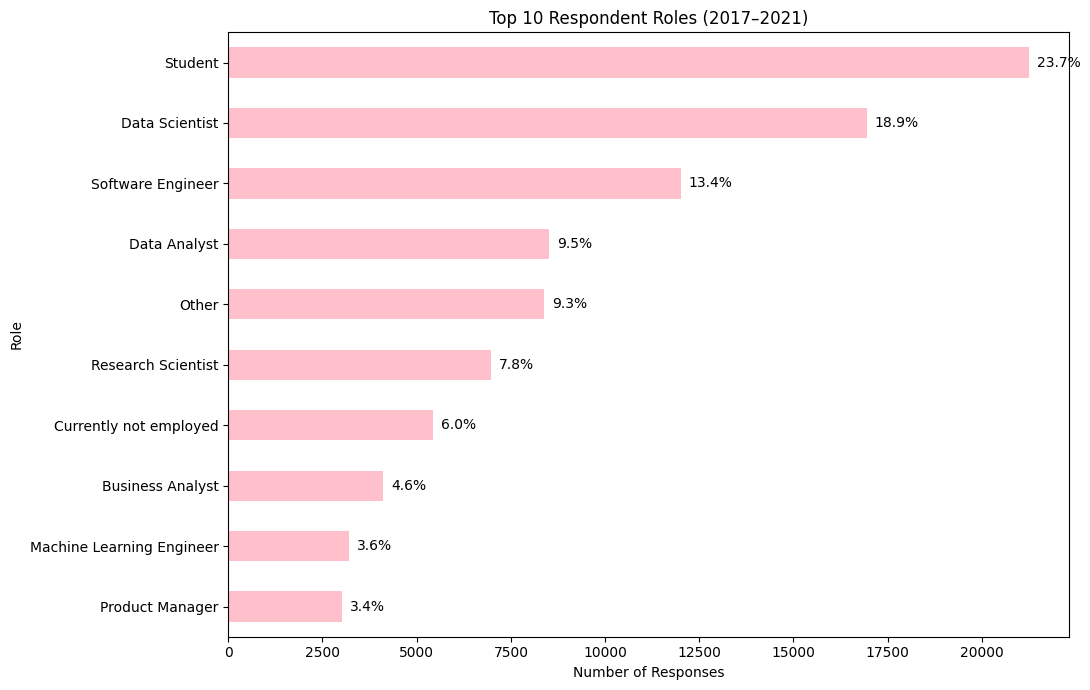

In [267]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 7))

role = (
    df.iloc[1:, 6]
    .value_counts()
    .head(10)
    .sort_values()
)

percentage = role / role.sum() * 100

# Light grey for all bars
colors = ['pink'] * len(role)


ax = role.plot(
    kind='barh',
    color=colors
)

ax.set_xlabel('Number of Responses')
ax.set_ylabel('Role')
ax.set_title('Top 10 Respondent Roles (2017–2021)')

# Add percentage labels
for i, (count, pct) in enumerate(zip(role, percentage)):
    ax.text(
        count + role.max() * 0.01,
        i,
        f'{pct:.1f}%',
        va='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

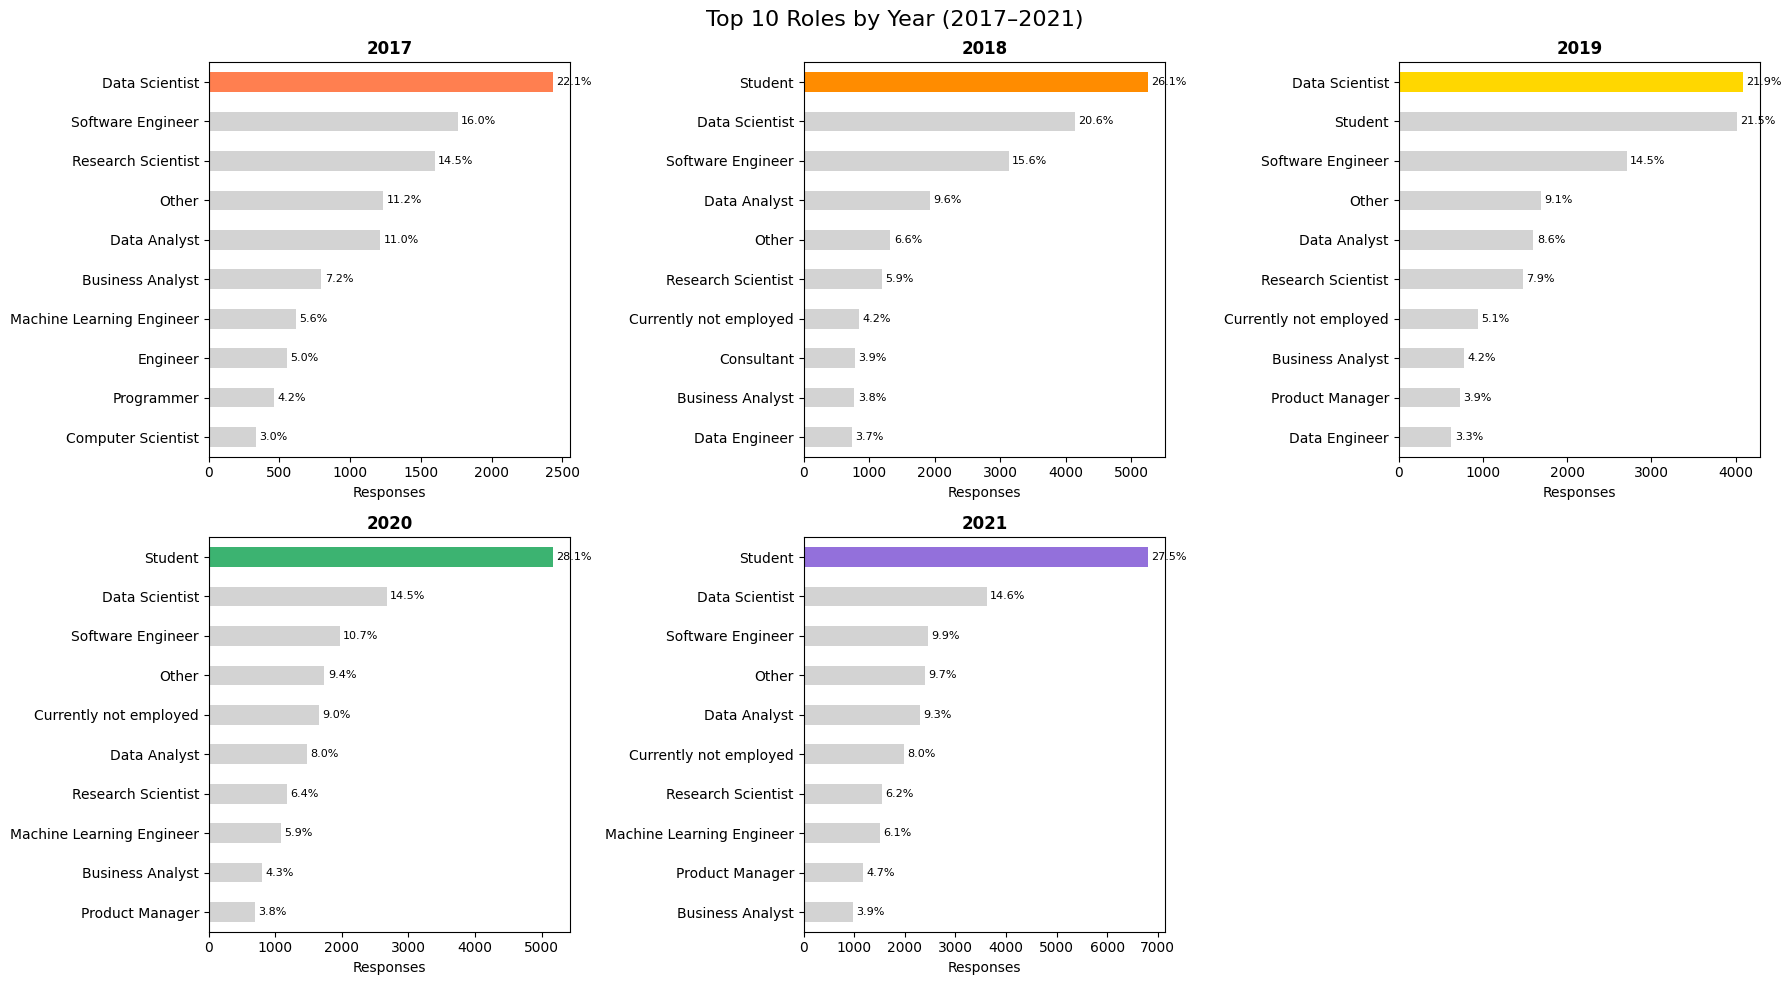

In [268]:
import matplotlib.pyplot as plt

years = sorted(df['-_Year'].dropna().unique())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

highlight_colors = [
    'coral',
    'darkorange',
    'gold',
    'mediumseagreen',
    'mediumpurple'
]

for ax, year, highlight in zip(axes, years, highlight_colors):

    role_count = (
        df[df['-_Year'] == year]
        .iloc[:, 6]
        .value_counts()
        .head(10)
        .sort_values()
    )

    percentage = role_count / role_count.sum() * 100

    # Make all bars light grey
    colors = ['lightgrey'] * len(role_count)

    # Highlight the most common role
    colors[-1] = highlight

    role_count.plot(
        kind='barh',
        ax=ax,
        color=colors
    )

    # Add percentage labels
    for i, (count, pct) in enumerate(zip(role_count, percentage)):
        ax.text(
            count + role_count.max()*0.01,
            i,
            f'{pct:.1f}%',
            va='center',
            fontsize=8
        )

    ax.set_title(f'{year}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Responses')
    ax.set_ylabel('')

# Remove the empty subplot
fig.delaxes(axes[-1])

plt.suptitle('Top 10 Roles by Year (2017–2021)', fontsize=16)
plt.tight_layout()
plt.show()

In [269]:
# check data in experience
df.iloc[1:, 7].unique()

array(['20+ years', '1-3 years', '< 1 years', '5-10 years', '3-5 years',
       '10-20 years', 'I have never written code', '1-2 years', nan,
       'I have never written code but I want to learn', '< 1 year',
       '20-30 years', '30-40 years',
       'I have never written code and I do not want to learn',
       '40+ years', 'More than 10 years', 'Less than a year',
       '3 to 5 years', '6 to 10 years', '1 to 2 years',
       "I don't write code to analyze data"], dtype=object)

In [276]:
import numpy as np

df.iloc[1:, 7] = df.iloc[1:, 7].replace({
    # Less than one year
    "< 1 years": "< 1 year",
    "Less than a year": "< 1 year",

    # 1–2 years
    "1-3 years": "1-2 years",
    "1 to 2 years": "1-2 years",

    # 3–5 years
    "3 to 5 years": "3-5 years",

    # 6–10 years
    "6 to 10 years": "5-10 years",

    # More than 10 years
    "More than 10 years": "10+ years",
    "10-20 years": "10+ years",
    "20-30 years": "10+ years",
    "30-40 years": "10+ years",
    "40+ years": "10+ years",
    "20+ years": "10+ years",

    # Never coded
    "I have never written code but I want to learn": "Never coded",
    "I have never written code and I do not want to learn": "Never coded",
    "I have never written code": "Never coded",
    "I don't write code to analyze data": "Never coded"
})

# Check cleaned categories
sorted(df.iloc[1:, 7].dropna().unique())

['1-2 years',
 '10+ years',
 '3-5 years',
 '5-10 years',
 '< 1 year',
 'Never coded']

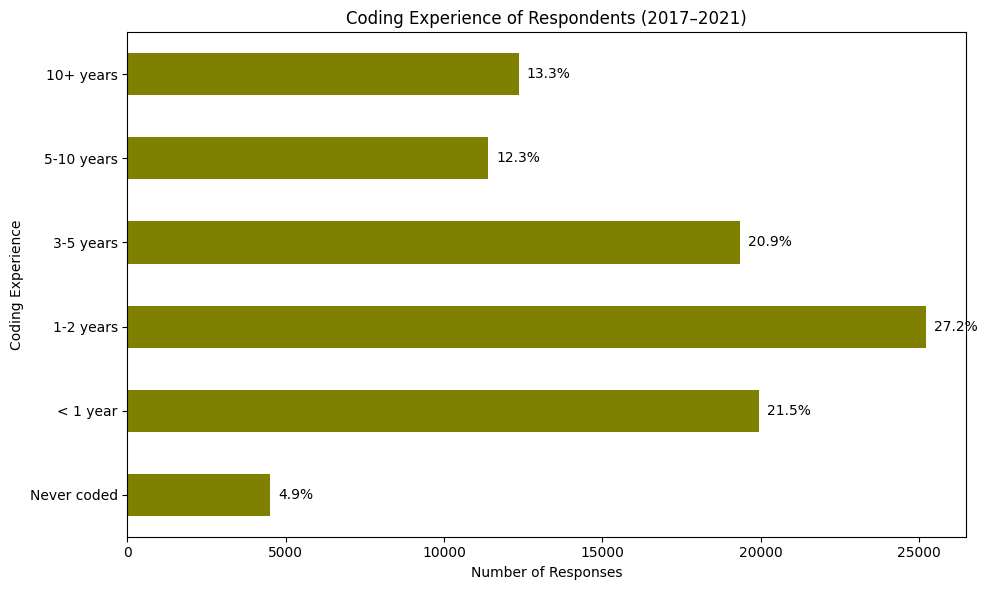

In [277]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

experience_count = (
    df.iloc[1:, 7]
    .value_counts()
)

# Display in logical order
experience_order = [
    "Never coded",
    "< 1 year",
    "1-2 years",
    "3-5 years",
    "5-10 years",
    "10+ years"
]

experience_count = experience_count.reindex(experience_order, fill_value=0)

percentage = experience_count / experience_count.sum() * 100

# Highlight the largest category
colors = ['olive'] * len(experience_count)

ax = experience_count.plot(
    kind='barh',
    color=colors
)

ax.set_xlabel('Number of Responses')
ax.set_ylabel('Coding Experience')
ax.set_title('Coding Experience of Respondents (2017–2021)')

for i, (count, pct) in enumerate(zip(experience_count, percentage)):
    if count > 0:
        ax.text(
            count + experience_count.max()*0.01,
            i,
            f'{pct:.1f}%',
            va='center'
        )

plt.tight_layout()
plt.show()

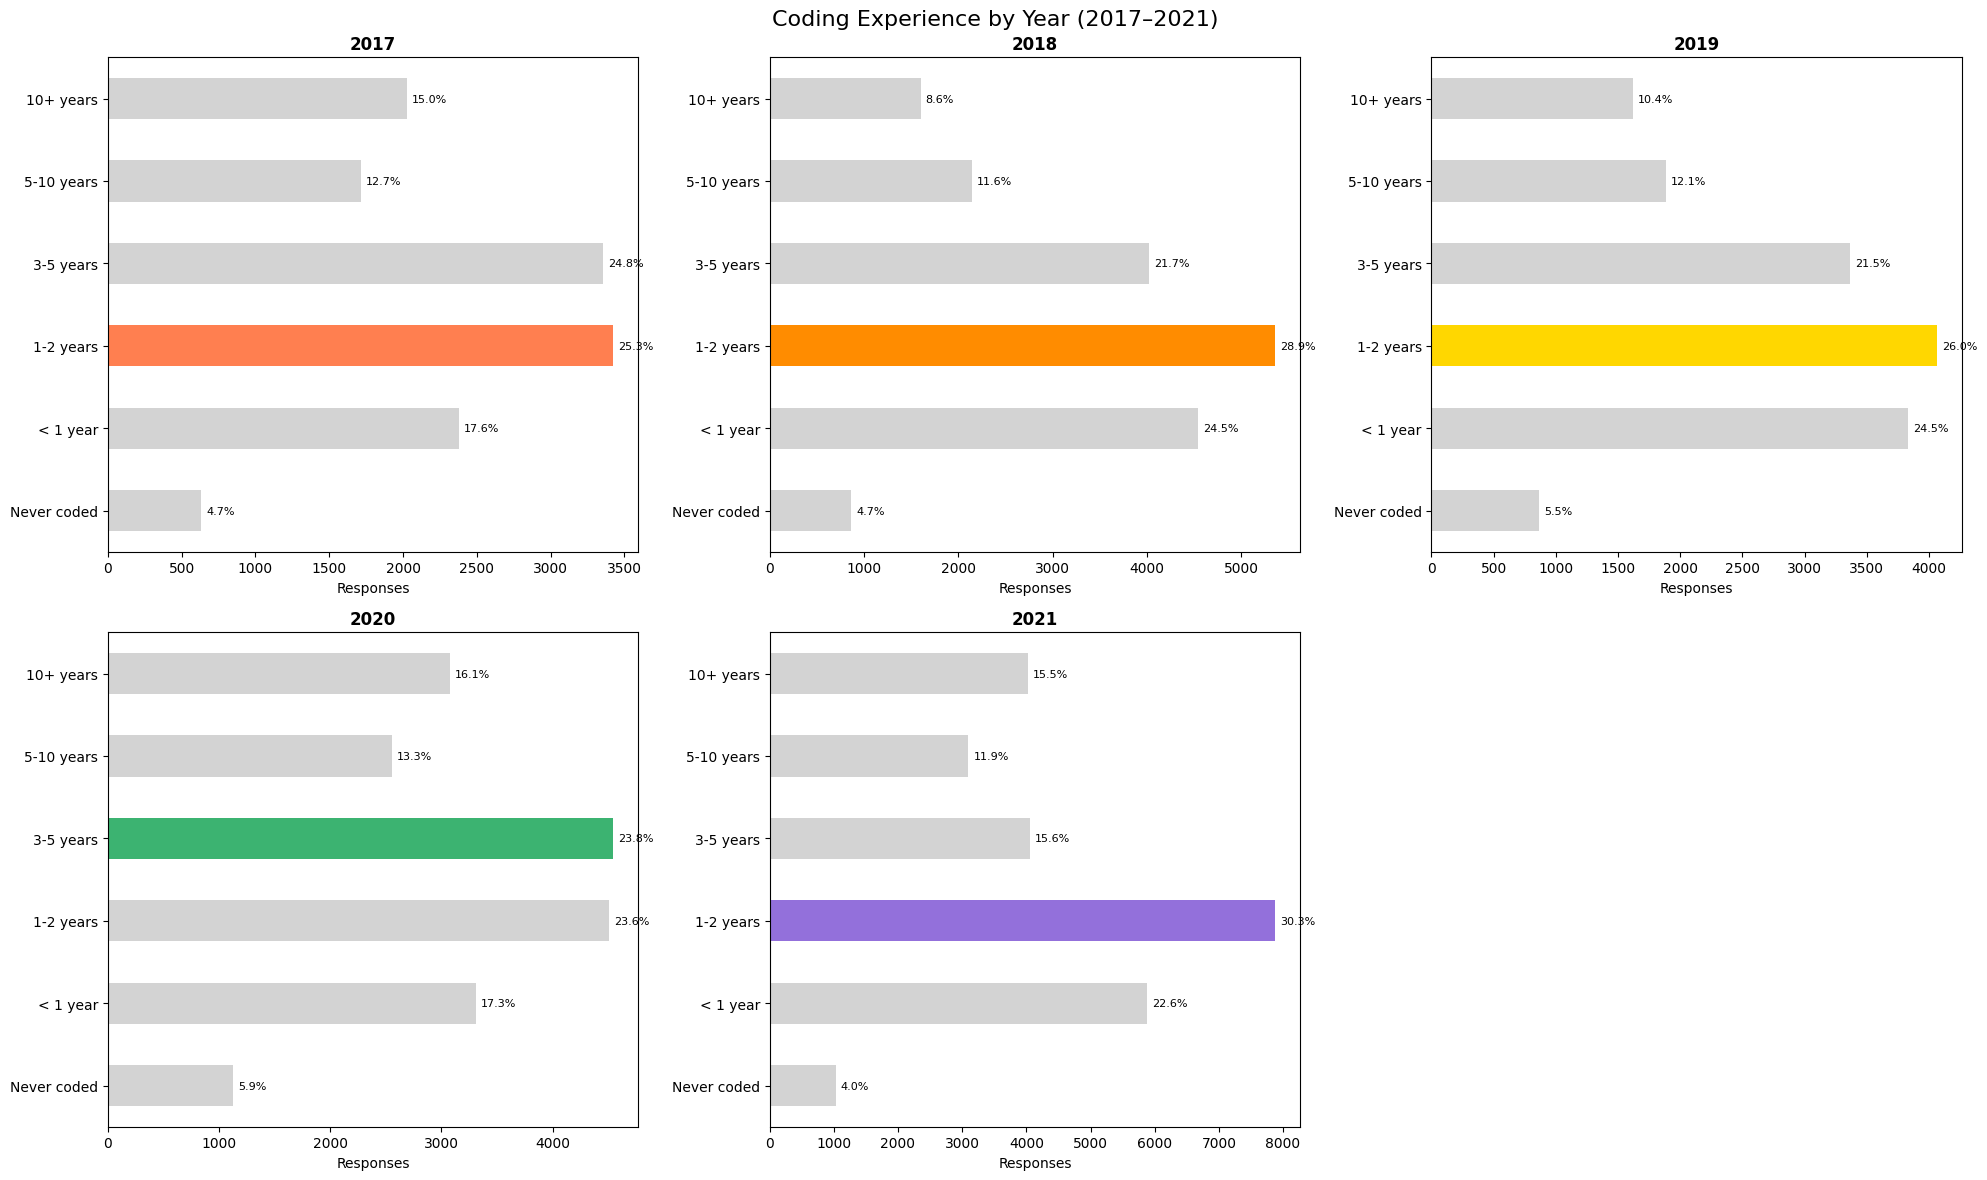

In [278]:
import matplotlib.pyplot as plt

experience_order = [
    "Never coded",
    "< 1 year",
    "1-2 years",
    "3-5 years",
    "5-10 years",
    "10+ years"
]

years = sorted(df['-_Year'].dropna().unique())

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

highlight_colors = [
    'coral',
    'darkorange',
    'gold',
    'mediumseagreen',
    'mediumpurple'
]

for ax, year, highlight in zip(axes, years, highlight_colors):

    experience_count = (
        df[df['-_Year'] == year]
        .iloc[:, 7]
        .value_counts()
        .reindex(experience_order, fill_value=0)
    )

    percentage = experience_count / experience_count.sum() * 100

    colors = ['lightgrey'] * len(experience_count)
    colors[experience_count.argmax()] = highlight

    experience_count.plot(
        kind='barh',
        ax=ax,
        color=colors
    )

    for i, (count, pct) in enumerate(zip(experience_count, percentage)):
        if count > 0:
            ax.text(
                count + experience_count.max()*0.01,
                i,
                f'{pct:.1f}%',
                va='center',
                fontsize=8
            )

    ax.set_title(str(year), fontsize=12, fontweight='bold')
    ax.set_xlabel('Responses')
    ax.set_ylabel('')

# Remove unused subplot
fig.delaxes(axes[-1])

plt.suptitle('Coding Experience by Year (2017–2021)', fontsize=16)
plt.tight_layout()
plt.show()

In [279]:
df.head()

,-_Year,Time from Start to Finish (seconds)_Duration (in seconds),Q1_What is your age (# years)?,Q2_What is your gender? - Selected Choice,Q3_In which country do you currently reside?,Q4_What is the highest level of formal education that you have attained or plan to attain within the next 2 years?,Q5_Select the title most similar to your current role (or most recent title if retired): - Selected Choice,Q6_For how many years have you been writing code and/or programming?,Q7_Part_1_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Python,Q7_Part_2_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - R,...,"Q38_B_Part_1_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Neptune.ai","Q38_B_Part_2_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Weights & Biases","Q38_B_Part_3_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Comet.ml","Q38_B_Part_4_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Sacred + Omniboard","Q38_B_Part_5_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - TensorBoard","Q38_B_Part_6_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Guild.ai","Q38_B_Part_7_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Polyaxon","Q38_B_Part_9_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Domino Model Monitor","Q38_B_Part_11_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - None","Q38_B_OTHER_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Other"
2,2021,910,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,784,50-54,Male,Indonesia,Master's degree,Product Manager,10+ years,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021,924,22-24,Male,Pakistan,Master's degree,Software Engineer,1-2 years,Python,NaN,...,NaN,NaN,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,NaN
5,2021,575,45-49,Male,Mexico,Doctoral degree,Research Scientist,10+ years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2021,781,45-49,Male,India,Doctoral degree,Other,< 1 year,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [293]:
df.iloc[ 0,8:30]

Q7_Part_1_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Python                                                                                             Python
Q7_Part_2_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - R                                                                                                       R
Q7_Part_3_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - SQL                                                                                                   NaN
Q7_Part_4_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - C                                                                                                     NaN
Q7_Part_5_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - C++             

## Programming Languages Analysis

From the dataset above, we can observe that columns 8 to 21 represent responses to a similar question pattern related to programming languages:

**"What programming languages do you use on a regular basis? (Select all that apply)"**

Each column corresponds to a specific programming language option (Python, R, SQL, C, C++, Java, etc.), and the values indicate whether the respondent selected that language or not (NaN meaning not selected).

Since all these columns belong to the same multi-select question, we will:

- Combine (merge) all programming-related columns into a single structured DataFrame.
- Transform the data into a more analysis-friendly format.
- Calculate the frequency of each programming language.
- Visualize the results to gain better insights into language popularity.

This approach will help us:

- Identify the most commonly used programming languages.
- Compare usage patterns across respondents.
- Generate clear and meaningful visualizations for better understanding.

By restructuring the data properly, we can extract more valuable insights from the survey responses.


In [294]:

for i in range(8,21):
    print(df.iloc[1:,i].unique())

[nan 'Python']
[nan 'R']
['SQL' nan]
['C' nan]
['C++' nan]
['Java' nan]
[nan 'Javascript']
[nan 'Julia']
[nan 'Swift']
[nan 'Bash']
[nan 'MATLAB']
[nan]
[nan 'Other']


In [295]:
# replaced same categories
df.iloc[1:, 14] = df.iloc[1:, 14].replace({"Javascript/Typescript": "Javascript"})

In [296]:
programming = {}
for i in range(8,21):
    programming.update(dict(df.iloc[:, i].value_counts()))
programming = pd.DataFrame(programming.items(), columns = ["Languages", "Count"])
programming

,Languages,Count
0,Python,65942
1,R,20884
2,SQL,33090
3,C,9696
4,C++,11618
5,Java,14402
6,Javascript,12750
7,Julia,797
8,Swift,440
9,Bash,8737


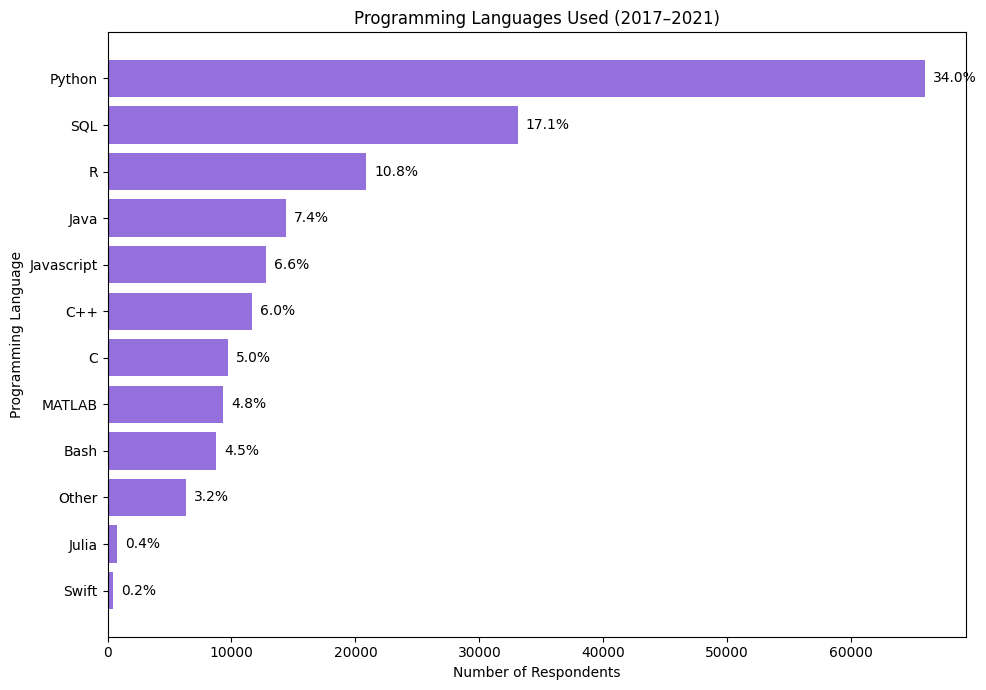

In [297]:
# Count languages across all years
programming = {}

for i in range(8, 21):
    programming.update(dict(df.iloc[1:, i].value_counts()))

programming = pd.DataFrame(
    programming.items(),
    columns=["Language", "Count"]
)

programming["Percent"] = (
    programming["Count"] /
    programming["Count"].sum() * 100
)

programming = programming.sort_values("Count")

# Highlight Python
colors = ['mediumpurple'] * len(programming)

plt.figure(figsize=(10, 7))

ax = plt.gca()

ax.barh(
    programming["Language"],
    programming["Count"],
    color=colors
)

for i, (count, pct) in enumerate(zip(programming["Count"], programming["Percent"])):
    ax.text(
        count + programming["Count"].max()*0.01,
        i,
        f"{pct:.1f}%",
        va='center'
    )

ax.set_xlabel("Number of Respondents")
ax.set_ylabel("Programming Language")
ax.set_title("Programming Languages Used (2017–2021)")

plt.tight_layout()
plt.show()

## Programming Languages over Time

In [298]:
df.iloc[:, 8:21]

,Q7_Part_1_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Python,Q7_Part_2_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - R,Q7_Part_3_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - SQL,Q7_Part_4_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - C,Q7_Part_5_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - C++,Q7_Part_6_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Java,Q7_Part_7_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Javascript,Q7_Part_8_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Julia,Q7_Part_9_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Swift,Q7_Part_10_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Bash,Q7_Part_11_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - MATLAB,Q7_Part_12_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - None,Q7_OTHER_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Other
2,Python,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,SQL,C,C++,Java,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Python,NaN,NaN,NaN,C++,Java,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Python,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Python,NaN,NaN,C,NaN,NaN,NaN,NaN,NaN,NaN,MATLAB,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106298,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106301,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Find 2017 programming language columns


In [299]:
programming_df = df.iloc[:, [0] + list(range(8, 21))]
programming_df.head()

,-_Year,Q7_Part_1_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Python,Q7_Part_2_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - R,Q7_Part_3_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - SQL,Q7_Part_4_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - C,Q7_Part_5_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - C++,Q7_Part_6_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Java,Q7_Part_7_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Javascript,Q7_Part_8_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Julia,Q7_Part_9_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Swift,Q7_Part_10_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Bash,Q7_Part_11_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - MATLAB,Q7_Part_12_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - None,Q7_OTHER_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Other
2,2021,Python,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,NaN,NaN,SQL,C,C++,Java,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021,Python,NaN,NaN,NaN,C++,Java,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2021,Python,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2021,Python,NaN,NaN,C,NaN,NaN,NaN,NaN,NaN,NaN,MATLAB,NaN,NaN


In [300]:
programming_df.replace({
    'Python':1,
    'R':1,
    'SQL':1,
    'C':1,
    'C++':1,
    'Java':1,
    'Javascript':1,
    'Julia':1,
    'Swift':1,
    'Bash':1,
    'MATLAB':1,
    'None': 1,
    'Other': 1,
    np.nan: 0
}, inplace=True)
programming_df.head()

,-_Year,Q7_Part_1_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Python,Q7_Part_2_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - R,Q7_Part_3_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - SQL,Q7_Part_4_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - C,Q7_Part_5_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - C++,Q7_Part_6_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Java,Q7_Part_7_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Javascript,Q7_Part_8_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Julia,Q7_Part_9_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Swift,Q7_Part_10_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Bash,Q7_Part_11_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - MATLAB,Q7_Part_12_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - None,Q7_OTHER_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Other
2,2021,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2021,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2021,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2021,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2021,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [301]:
programming_df2 = programming_df.groupby('-_Year').sum()
programming_df2

,Q7_Part_1_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Python,Q7_Part_2_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - R,Q7_Part_3_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - SQL,Q7_Part_4_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - C,Q7_Part_5_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - C++,Q7_Part_6_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Java,Q7_Part_7_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Javascript,Q7_Part_8_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Julia,Q7_Part_9_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Swift,Q7_Part_10_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Bash,Q7_Part_11_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - MATLAB,Q7_Part_12_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - None,Q7_OTHER_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Other
-_Year,,,,,,,,,,,,,
2017,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018,15711.0,6685.0,8267.0,0.0,0.0,3999.0,3249.0,230.0,0.0,2708.0,2652.0,0.0,624.0
2019,12841.0,4588.0,6532.0,1672.0,2256.0,2267.0,2174.0,0.0,0.0,2037.0,1516.0,0.0,1148.0
2020,15530.0,4277.0,7535.0,3315.0,3827.0,3367.0,2995.0,262.0,198.0,1776.0,2217.0,0.0,1945.0
2021,21860.0,5334.0,10756.0,4709.0,5535.0,4769.0,4332.0,305.0,242.0,2216.0,2935.0,0.0,2575.0


In [302]:
programming_df2 = pd.DataFrame({
    'year': programming_df2.index,
    'python': programming_df2.iloc[:, 0],
    'R': programming_df2.iloc[:, 1],
    'SQL': programming_df2.iloc[:, 2],
    'C': programming_df2.iloc[:, 3],
    'C++': programming_df2.iloc[:, 4],
    'Java': programming_df2.iloc[:, 5],
    'Javascript':programming_df2.iloc[:,6],
    'Julia': programming_df2.iloc[:, 7],
    'Swift': programming_df2.iloc[:, 8],
    'Bash': programming_df2.iloc[:, 9],
    'MATLAB': programming_df2.iloc[:, 10],
    'None': programming_df2.iloc[:, 11],
    'Other': programming_df2.iloc[:, 12]
})
programming_df2

,year,python,R,SQL,C,C++,Java,Javascript,Julia,Swift,Bash,MATLAB,None,Other
-_Year,,,,,,,,,,,,,,
2017,2017,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018,2018,15711.0,6685.0,8267.0,0.0,0.0,3999.0,3249.0,230.0,0.0,2708.0,2652.0,0.0,624.0
2019,2019,12841.0,4588.0,6532.0,1672.0,2256.0,2267.0,2174.0,0.0,0.0,2037.0,1516.0,0.0,1148.0
2020,2020,15530.0,4277.0,7535.0,3315.0,3827.0,3367.0,2995.0,262.0,198.0,1776.0,2217.0,0.0,1945.0
2021,2021,21860.0,5334.0,10756.0,4709.0,5535.0,4769.0,4332.0,305.0,242.0,2216.0,2935.0,0.0,2575.0


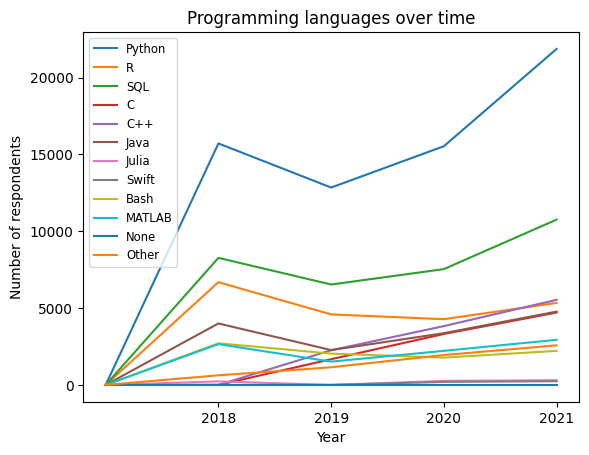

In [304]:
# select columns for each language
python = programming_df2['python']
r = programming_df2['R']
sql = programming_df2['SQL']
c = programming_df2['C']
cpp = programming_df2['C++']
java = programming_df2['Java']
julia = programming_df2['Julia']
swift = programming_df2['Swift']
bash = programming_df2['Bash']
matlab = programming_df2['MATLAB']
none = programming_df2['None']
other = programming_df2['Other']

# plot line chart for each language
plt.plot(programming_df2['year'], python, label='Python')
plt.plot(programming_df2['year'], r, label='R')
plt.plot(programming_df2['year'], sql, label='SQL')
plt.plot(programming_df2['year'], c, label='C')
plt.plot(programming_df2['year'], cpp, label='C++')
plt.plot(programming_df2['year'], java, label='Java')
plt.plot(programming_df2['year'], julia, label='Julia')
plt.plot(programming_df2['year'], swift, label='Swift')
plt.plot(programming_df2['year'], bash, label='Bash')
plt.plot(programming_df2['year'], matlab, label='MATLAB')
plt.plot(programming_df2['year'], none, label='None')
plt.plot(programming_df2['year'], other, label='Other')

# set chart title and labels
plt.title('Programming languages over time')
plt.xlabel('Year')
plt.ylabel('Number of respondents')
plt.xticks(range(2018, 2022))



# show legend
plt.legend(fontsize='small')

# show plot
plt.show()

## Trend in IDE on daily Basis

In [305]:
df.iloc[1:, 22].unique()

array([nan, 'Jupyter (JupyterLab, Jupyter Notebooks, etc) ',
       'Jupyter/IPython'], dtype=object)

In [308]:
df.iloc[1:, 22] = df.iloc[1:, 22].replace({"Jupyter (JupyterLab, Jupyter Notebooks, etc) ": "JupyterLab, Jupyter Notebooks, etc", 
                                         "Jupyter/IPython": "JupyterLab, Jupyter Notebooks, etc"})

In [310]:
df.iloc[1:, 25].unique()

array([nan, ' PyCharm ', 'PyCharm'], dtype=object)

In [314]:
df.iloc[1:, 25] = df.iloc[1:, 25].replace({" PyCharm ": "PyCharm"})

In [315]:
for i in range(22,33):
    print(df.iloc[1:,i].unique())

[nan 'JupyterLab, Jupyter Notebooks, etc']
[nan ' RStudio ' 'RStudio']
[nan 'Visual Studio' ' Visual Studio / Visual Studio Code '
 'Visual Studio/ Visual Studio Code']
[nan 'PyCharm']
[nan '  Spyder  ' 'Spyder']
['  Notepad++  ' nan 'Notepad++']
[nan '  Sublime Text  ' 'Sublime Text']
[nan '  Vim / Emacs  ' 'Vim']
[nan ' MATLAB ' 'MATLAB']
[nan]
[nan 'Other']


In [316]:
df.iloc[1:, 24]=df.iloc[1:, 24].replace({"Visual Studio/ Visual Studio Code": "Visual Studio", ' Visual Studio / Visual Studio Code ': 'Visual Studio'})
df.iloc[1:, 23] = df.iloc[1:,23].replace({' RStudio ': 'RStudio'})
df.iloc[1:,26]=df.iloc[1:,26].replace({'  Spyder  ': 'Spyder'})
df.iloc[1:,27]=df.iloc[1:,27].replace({'  Notepad++  ': 'Notepad++'})
df.iloc[1:,28]=df.iloc[1:,28].replace({'  Sublime Text  ': 'Sublime Text'})
df.iloc[1:,30]=df.iloc[1:,30].replace({' MATLAB ':'MATLAB'})
df.iloc[1:,29]=df.iloc[1:,29].replace({'Vim':'Vim / Emacs', '  Vim / Emacs  ': 'Vim / Emacs'})
df.iloc[1:,22]=df.iloc[1:, 22] = df.iloc[1:, 22].replace({"JupyterLab, Jupyter Notebooks, etc": "Jupyter"})

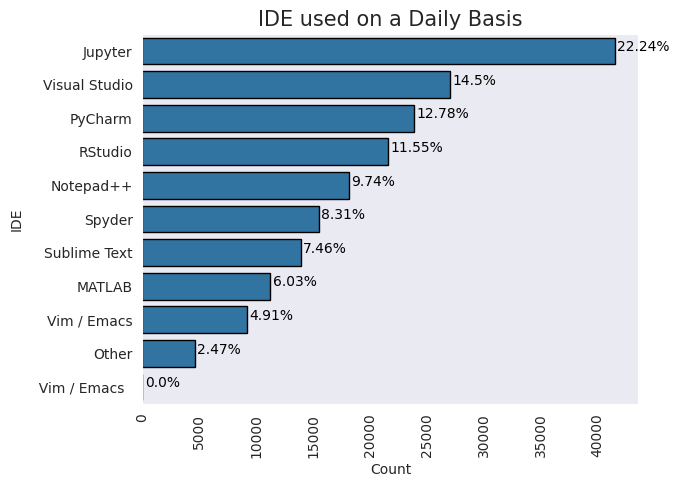

In [317]:
ide = {}
for i in range(22, 33):
    ide.update(dict(df.iloc[:, i].value_counts()))
ide = pd.DataFrame(ide.items(), columns = ["IDE", "Count"])

# calculate percentage of total and sort by descending order
ide["Percent"] = ide["Count"] / ide["Count"].sum() * 100
ide = ide.sort_values(by="Count", ascending=False)

sns.set_style("dark")
p = sns.barplot(x="Count", y="IDE", data=ide, edgecolor="black")
p.set_title("IDE used on a Daily Basis", fontsize=15)
plt.xticks(rotation=90)
plt.xlabel("Count")
plt.ylabel("IDE")
# add percentage labels to the bars
for i, v in enumerate(ide["Percent"].round(2)):
    p.text(ide.iloc[i]["Count"] + 200, i, str(v) + "%", fontsize=10, color='black')
plt.show()

In [318]:
q9_df = df.iloc[:, [0] + list(range(22, 33))]
q9_df.head()

,-_Year,"Q9_Part_1_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - Jupyter (JupyterLab, Jupyter Notebooks, etc)",Q9_Part_2_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - RStudio,Q9_Part_3_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - Visual Studio / Visual Studio Code,Q9_Part_5_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - PyCharm,Q9_Part_6_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - Spyder,Q9_Part_7_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - Notepad++,Q9_Part_8_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - Sublime Text,Q9_Part_9_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - Vim / Emacs,Q9_Part_10_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - MATLAB,Q9_Part_12_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - None,Q9_OTHER_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - Other
2,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Vim / Emacs,NaN,NaN,NaN
3,2021,NaN,NaN,NaN,NaN,NaN,Notepad++,NaN,NaN,NaN,NaN,NaN
4,2021,NaN,NaN,NaN,PyCharm,NaN,NaN,NaN,NaN,NaN,NaN,Other
5,2021,NaN,NaN,NaN,NaN,Spyder,NaN,NaN,NaN,NaN,NaN,NaN
6,2021,NaN,NaN,NaN,NaN,Spyder,NaN,NaN,NaN,MATLAB,NaN,NaN


In [319]:
df.iloc[1:,29].unique()

array([nan, 'Vim / Emacs'], dtype=object)

In [320]:
# Replace count for each response
q9_df.replace({
    'Jupyter': 1,
    'RStudio': 1,
    'Visual Studio': 1,
    'PyCharm': 1,
    'Spyder': 1,
    'Notepad++': 1,
    'Sublime Text': 1,
    'Vim / Emacs': 1,
    'MATLAB': 1,
    'None': 1,
    'Other': 1,
    np.nan: 0
}, inplace=True)
q9_df.iloc[:, 1:] = q9_df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

# Group by year and sum up the counts for each IDE
q9_df2 = q9_df.groupby('-_Year').sum()
q9_df2

,"Q9_Part_1_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - Jupyter (JupyterLab, Jupyter Notebooks, etc)",Q9_Part_2_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - RStudio,Q9_Part_3_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - Visual Studio / Visual Studio Code,Q9_Part_5_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - PyCharm,Q9_Part_6_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - Spyder,Q9_Part_7_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - Notepad++,Q9_Part_8_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - Sublime Text,Q9_Part_9_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - Vim / Emacs,Q9_Part_10_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - MATLAB,Q9_Part_12_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - None,Q9_OTHER_Which of the following integrated development environments (IDE's) do you use on a regular basis? (Select all that apply) - Selected Choice - Other
-_Year,,,,,,,,,,,
2017,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018,14010.0,8503.0,7809.0,7060.0,5339.0,7831.0,5985.0,4240.0,5671.0,0.0,1257.0
2019,10804.0,4455.0,4534.0,4224.0,3085.0,3281.0,2655.0,1782.0,1768.0,0.0,691.0
2020,11211.0,3826.0,2445.0,5099.0,3290.0,3132.0,2452.0,1502.0,1604.0,0.0,1162.0
2021,5488.0,4771.0,12281.0,7468.0,3794.0,3937.0,2839.0,1645.0,2203.0,0.0,1491.0


In [321]:
q9_df2 = pd.DataFrame({
    'year': q9_df2.index,
    'Jupyter': q9_df2.iloc[:, 0],
    'RStudio': q9_df2.iloc[:, 1],
    'Visual Studio': q9_df2.iloc[:, 2],
    'PyCharm': q9_df2.iloc[:, 3],
    'Spyder': q9_df2.iloc[:, 4],
    'Notepad++': q9_df2.iloc[:, 5],
    'Sublime Text': q9_df2.iloc[:, 6],
    'Vim / Emacs': q9_df2.iloc[:, 7],
    'MATLAB': q9_df2.iloc[:, 8],
    'None': q9_df2.iloc[:, 9],
    'Other': q9_df2.iloc[:, 10]
})
q9_df2

,year,Jupyter,RStudio,Visual Studio,PyCharm,Spyder,Notepad++,Sublime Text,Vim / Emacs,MATLAB,None,Other
-_Year,,,,,,,,,,,,
2017,2017,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018,2018,14010.0,8503.0,7809.0,7060.0,5339.0,7831.0,5985.0,4240.0,5671.0,0.0,1257.0
2019,2019,10804.0,4455.0,4534.0,4224.0,3085.0,3281.0,2655.0,1782.0,1768.0,0.0,691.0
2020,2020,11211.0,3826.0,2445.0,5099.0,3290.0,3132.0,2452.0,1502.0,1604.0,0.0,1162.0
2021,2021,5488.0,4771.0,12281.0,7468.0,3794.0,3937.0,2839.0,1645.0,2203.0,0.0,1491.0


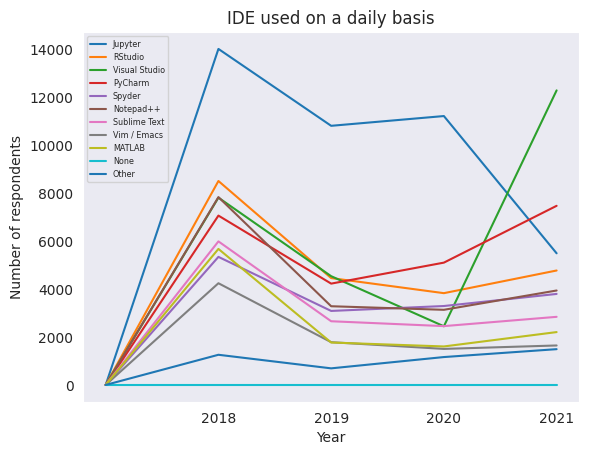

In [322]:
# select columns for each language
Jupyter = q9_df2['Jupyter']
RStudio = q9_df2['RStudio']
Visual_Studio = q9_df2['Visual Studio']
PyCharm = q9_df2['PyCharm']
Spyder = q9_df2['Spyder']
Notepad = q9_df2['Notepad++']
Sublime_Text = q9_df2['Sublime Text']
Vim_Emacs = q9_df2['Vim / Emacs']
MATLAB = q9_df2['MATLAB']
none = q9_df2['None']
Other = q9_df2['Other']

# plot line chart for each language
plt.plot(q9_df2['year'], Jupyter, label='Jupyter')
plt.plot(q9_df2['year'], RStudio, label='RStudio')
plt.plot(q9_df2['year'], Visual_Studio, label='Visual Studio')
plt.plot(q9_df2['year'], PyCharm, label='PyCharm')
plt.plot(q9_df2['year'], Spyder, label='Spyder')
plt.plot(q9_df2['year'], Notepad, label='Notepad++')
plt.plot(q9_df2['year'], Sublime_Text, label='Sublime Text')
plt.plot(q9_df2['year'], Vim_Emacs, label='Vim / Emacs')
plt.plot(q9_df2['year'], MATLAB, label='MATLAB')
plt.plot(q9_df2['year'], none, label='None')
plt.plot(q9_df2['year'], Other, label='Other')


# set chart title and labels
plt.title('IDE used on a daily basis')
plt.xlabel('Year')
plt.ylabel('Number of respondents')
plt.xticks(range(2018, 2022))



# show legend
plt.legend(fontsize='xx-small')

# show plot
plt.show()

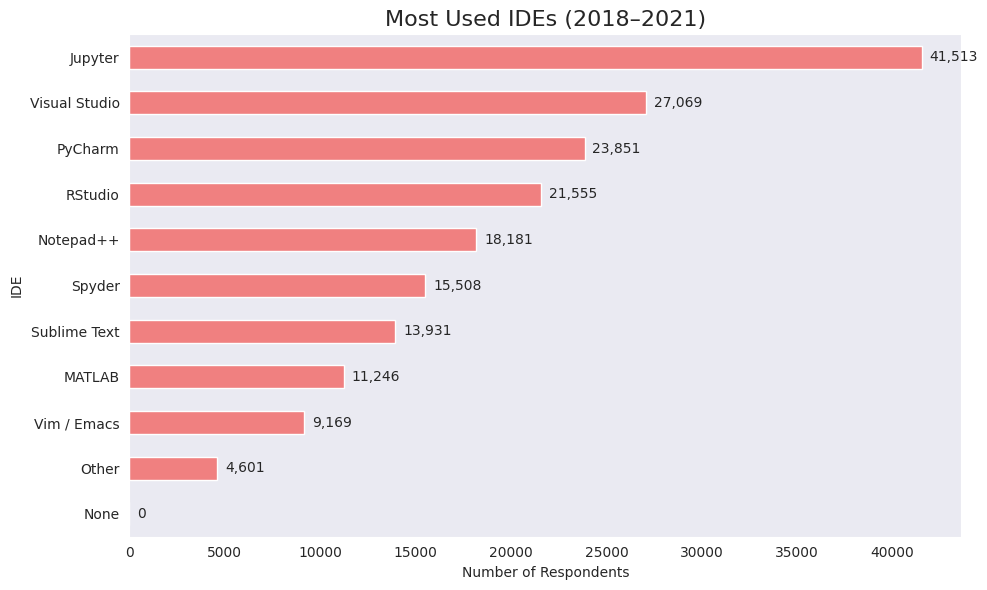

In [324]:

ide_total = (
    q9_df2.drop(columns='year')
    .sum()
    .sort_values()
)

plt.figure(figsize=(10,6))

ax = ide_total.plot(
    kind='barh',
    color='lightcoral'
)

plt.title(
    'Most Used IDEs (2018–2021)',
    fontsize=16
)

plt.xlabel('Number of Respondents')
plt.ylabel('IDE')

for i, v in enumerate(ide_total):
    ax.text(
        v + ide_total.max()*0.01,
        i,
        f'{v:,.0f}',
        va='center'
    )

plt.tight_layout()
plt.show()

## Trend in Ml Framework

In [326]:
df.iloc[1:, 66].unique()

array(['Under 1 year', 'I do not use machine learning methods',
       '5-10 years', '10-20 years', '2-3 years', nan, '1-2 years',
       '4-5 years', '3-4 years', '20 or more years', '< 1 years',
       '10-15 years', '20+ years',
       'I have never studied machine learning but plan to learn in the future',
       '< 1 year',
       'I have never studied machine learning and I do not plan to'],
      dtype=object)

In [327]:
df.iloc[1:, 66] = df.iloc[1:, 66].replace({"Under 1 year": "< 1 year", 
                                           "< 1 years": "< 1 year",
                                           "20+ years": "20 or more years",
                                         "10-15 years": "10-20 years"})

In [328]:
for i in range(67,83):
    print(df.iloc[1:,i].unique())

['  Scikit-learn ' nan 'Scikit-Learn']
[nan '  TensorFlow ' 'TensorFlow']
[nan ' Keras ' 'Keras']
[nan ' PyTorch ' 'PyTorch']
[nan ' Fast.ai ' 'Fastai']
[nan ' MXNet ' 'Mxnet']
[nan ' Xgboost ' 'Xgboost']
[nan ' LightGBM ' 'lightgbm']
[nan ' CatBoost ' 'catboost']
[nan ' Prophet ' 'Prophet']
[nan ' H2O 3 ' 'H20']
[nan ' Caret ' 'Caret']
[nan ' Tidymodels ']
[nan ' JAX ']
[nan]
[nan 'Other']


In [329]:
df.iloc[1:,67] = df.iloc[1:,67].replace({'  Scikit-learn ':'Scikit-Learn'})
df.iloc[1:,68] = df.iloc[1:,68].replace({'  TensorFlow ': 'TensorFlow'})
df.iloc[1:,69] = df.iloc[1:,69].replace({' Keras ':'Keras'})
df.iloc[1:,70] = df.iloc[1:,70].replace({' PyTorch ':'PyTorch'})
df.iloc[1:,71] = df.iloc[1:,71].replace({' Fast.ai ':'Fastai'})
df.iloc[1:,72] = df.iloc[1:,72].replace({' MXNet ': 'Mxnet'})
df.iloc[1:,73] = df.iloc[1:,73].replace({' Xgboost ': 'Xgboost'})
df.iloc[1:,74] = df.iloc[1:,74].replace({' LightGBM ':'lightgbm'})
df.iloc[1:,75] = df.iloc[1:,75].replace({' CatBoost ':'catboost'})
df.iloc[1:,76] = df.iloc[1:,76].replace({' Prophet ':'Prophet'})
df.iloc[1:,77] = df.iloc[1:,77].replace({' H2O 3 ':'H20'})
df.iloc[1:,78] = df.iloc[1:,78].replace({' Caret ':'Caret'})

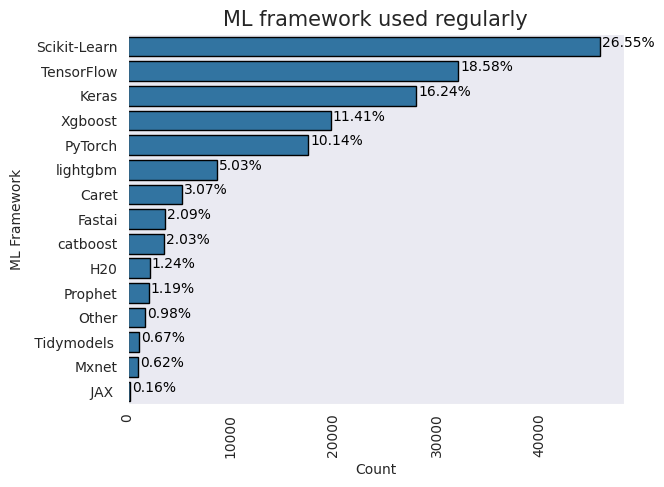

In [330]:
ml = {}

for i in range(67,83):
    counts = df.iloc[1:,i].value_counts()

    for framework, count in counts.items():
        ml[framework] = ml.get(framework,0) + count

ml = pd.DataFrame(
    ml.items(),
    columns=["ML Framework","Count"]
)
# calculate percentage of total and sort by descending order
ml["Percent"] = ml["Count"] / ml["Count"].sum() * 100
ml = ml.sort_values(by="Count", ascending=False)

sns.set_style("dark")
p = sns.barplot(x="Count", y="ML Framework", data=ml, edgecolor="black")
p.set_title("ML framework used regularly", fontsize=15)
plt.xticks(rotation=90)
plt.xlabel("Count")
plt.ylabel("ML Framework")
# add percentage labels to the bars
for i, v in enumerate(ml["Percent"].round(2)):
    p.text(ml.iloc[i]["Count"] + 200, i, str(v) + "%", fontsize=10, color='black')
plt.show()

In [331]:

# Store yearly results
ml_yearly = []

# Years available (exclude 2017 because ML framework question may not exist)
years = sorted(df['-_Year'].dropna().unique())

for year in years:

    # Filter year
    temp = df[df['-_Year'] == year]

    ml = {}

    # ML framework columns
    for col in range(67, 83):

        counts = temp.iloc[:, col].value_counts()

        for framework, count in counts.items():
            ml[framework] = ml.get(framework, 0) + count


    # Convert to dataframe
    year_df = pd.DataFrame(
        ml.items(),
        columns=['ML Framework', 'Count']
    )

    year_df['Year'] = year

    ml_yearly.append(year_df)


# Combine all years
ml_trend = pd.concat(
    ml_yearly,
    ignore_index=True
)

ml_trend.head()

,ML Framework,Count,Year
0,Scikit-Learn,12249,2018
1,TensorFlow,9981,2018
2,Keras,8136,2018
3,PyTorch,3826,2018
4,Fastai,1099,2018


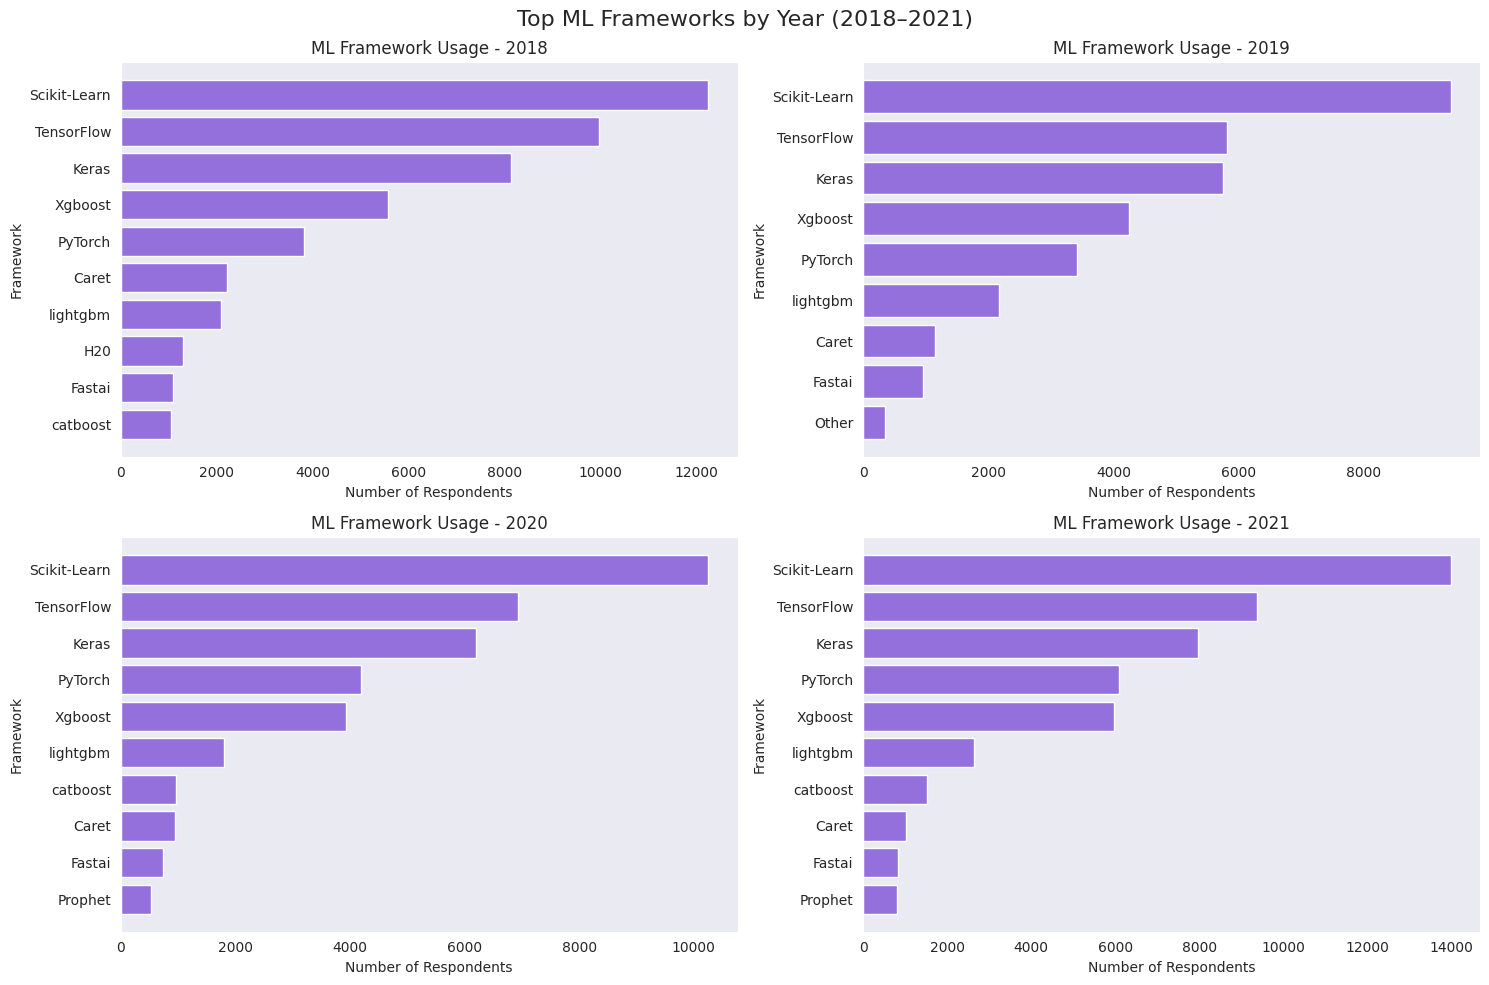

In [334]:
import matplotlib.pyplot as plt

years = [2018, 2019, 2020, 2021]

fig, axes = plt.subplots(
    2, 2,
    figsize=(15, 10)
)

axes = axes.flatten()


for ax, year in zip(axes, years):

    temp = (
        ml_trend[ml_trend['Year'] == year]
        .sort_values('Count')
        .tail(10)
    )

    ax.barh(
        temp['ML Framework'],
        temp['Count'],
        color='mediumpurple'
    )

    ax.set_title(
        f"ML Framework Usage - {year}",
        fontsize=12
    )

    ax.set_xlabel(
        "Number of Respondents"
    )

    ax.set_ylabel(
        "Framework"
    )


plt.suptitle(
    "Top ML Frameworks by Year (2018–2021)",
    fontsize=16
)

plt.tight_layout()
plt.show()

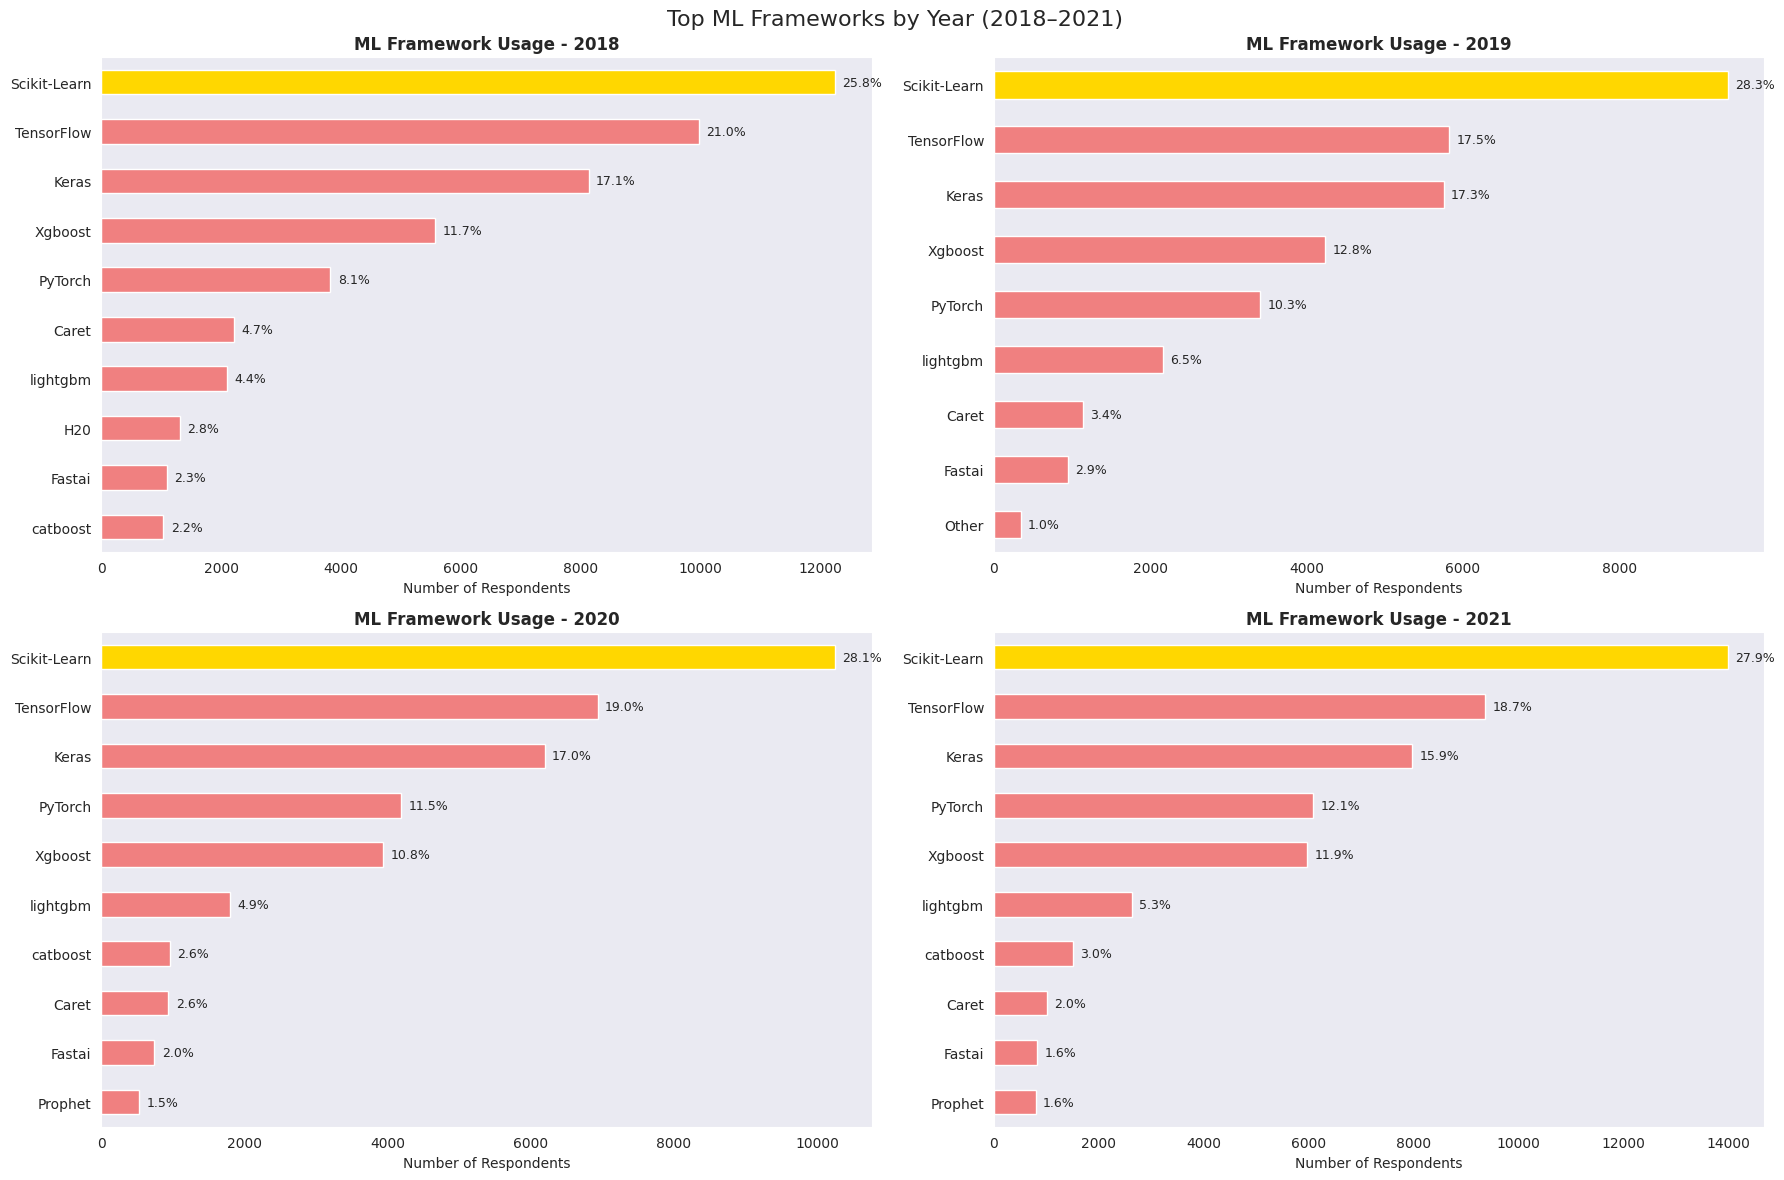

In [337]:
import matplotlib.pyplot as plt

years = [2018, 2019, 2020, 2021]

fig, axes = plt.subplots(
    2, 2,
    figsize=(18, 12)
)

axes = axes.flatten()

highlight_colors = [
    'gold',
    'gold',
    'gold',
    'gold'
]


for ax, year, highlight in zip(axes, years, highlight_colors):

    # Get framework data for year
    framework_count = (
        ml_trend[ml_trend['Year'] == year]
        .groupby('ML Framework')['Count']
        .sum()
        .sort_values()
        .tail(10)
    )


    # Calculate percentage
    percentage = (
        framework_count /
        framework_count.sum() * 100
    )


    # Colors: highlight highest framework
    colors = ['lightcoral'] * len(framework_count)

    top_index = framework_count.argmax()

    colors[top_index] = highlight


    # Plot
    framework_count.plot(
        kind='barh',
        ax=ax,
        color=colors
    )


    # Add percentage labels
    for i, (count, pct) in enumerate(
        zip(framework_count, percentage)
    ):
        ax.text(
            count + framework_count.max()*0.01,
            i,
            f'{pct:.1f}%',
            va='center',
            fontsize=9
        )


    ax.set_title(
        f'ML Framework Usage - {year}',
        fontsize=12,
        fontweight='bold'
    )

    ax.set_xlabel(
        'Number of Respondents'
    )

    ax.set_ylabel('')


# Remove empty axes if any
for ax in axes[len(years):]:
    fig.delaxes(ax)


plt.suptitle(
    'Top ML Frameworks by Year (2018–2021)',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [339]:
q16_df = df.iloc[:, [0] + list(range(66, 83))]
q16_df.head()

,-_Year,Q15_For how many years have you used machine learning methods?,Q16_Part_1_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - Scikit-learn,Q16_Part_2_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - TensorFlow,Q16_Part_3_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - Keras,Q16_Part_4_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - PyTorch,Q16_Part_5_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - Fast.ai,Q16_Part_6_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - MXNet,Q16_Part_7_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - Xgboost,Q16_Part_8_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - LightGBM,Q16_Part_9_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - CatBoost,Q16_Part_10_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - Prophet,Q16_Part_11_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - H2O 3,Q16_Part_12_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - Caret,Q16_Part_13_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - Tidymodels,Q16_Part_14_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - JAX,Q16_Part_17_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - None,Q16_OTHER_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - Other
2,2021,5-10 years,Scikit-learn,TensorFlow,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Caret,NaN,NaN,NaN,NaN
3,2021,< 1 year,Scikit-Learn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021,I do not use machine learning methods,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2021,5-10 years,Scikit-Learn,TensorFlow,Keras,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2021,10-20 years,Scikit-Learn,NaN,NaN,PyTorch,NaN,NaN,NaN,lightgbm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [341]:
q16_df.iloc[:, 2:] = q16_df.iloc[:, 2:].fillna(0).applymap(lambda x: 1 if x != 0 else 0)

In [343]:
q16_df2 = q16_df.groupby('-_Year').sum()
q16_df2.drop('Q15_For how many years have you used machine learning methods?',axis=1,inplace=True)
q16_df2.head()

,Q16_Part_1_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - Scikit-learn,Q16_Part_2_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - TensorFlow,Q16_Part_3_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - Keras,Q16_Part_4_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - PyTorch,Q16_Part_5_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - Fast.ai,Q16_Part_6_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - MXNet,Q16_Part_7_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - Xgboost,Q16_Part_8_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - LightGBM,Q16_Part_9_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - CatBoost,Q16_Part_10_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - Prophet,Q16_Part_11_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - H2O 3,Q16_Part_12_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - Caret,Q16_Part_13_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - Tidymodels,Q16_Part_14_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - JAX,Q16_Part_17_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - None,Q16_OTHER_Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - Other
-_Year,,,,,,,,,,,,,,,,
2017,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2018,12249,9981,8136,3826,1099,594,5571,2099,1037,732,1307,2220,0,0,0,536
2019,9390,5822,5756,3412,949,0,4243,2166,0,0,0,1139,0,0,0,342
2020,10250,6934,6192,4189,742,218,3935,1799,957,532,344,939,484,84,0,371
2021,13987,9371,7975,6088,824,252,5974,2635,1512,800,488,1009,678,190,0,439


In [344]:
q16_df2 = pd.DataFrame({
    'year': q16_df2.index,
    'Scikit-learn': q16_df2.iloc[:, 0],
    'TensorFlow': q16_df2.iloc[:, 1],
    'Keras': q16_df2.iloc[:, 2],
    'PyTorch': q16_df2.iloc[:, 3],
    'Fast.ai': q16_df2.iloc[:, 4],
    'MXNet': q16_df2.iloc[:, 5],
    'Xgboost': q16_df2.iloc[:, 6],
    'LightGBM': q16_df2.iloc[:, 7],
    'CatBoost': q16_df2.iloc[:, 8],
    'Prophet': q16_df2.iloc[:, 9],
    'H2O_3': q16_df2.iloc[:, 10],
    'Caret': q16_df2.iloc[:, 11],
    'Tidymodels': q16_df2.iloc[:, 12],
    'JAX': q16_df2.iloc[:, 13],
    'None': q16_df2.iloc[:, 14],
    'Other': q16_df2.iloc[:, 15]
})
q16_df2

,year,Scikit-learn,TensorFlow,Keras,PyTorch,Fast.ai,MXNet,Xgboost,LightGBM,CatBoost,Prophet,H2O_3,Caret,Tidymodels,JAX,None,Other
-_Year,,,,,,,,,,,,,,,,,
2017,2017,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2018,2018,12249,9981,8136,3826,1099,594,5571,2099,1037,732,1307,2220,0,0,0,536
2019,2019,9390,5822,5756,3412,949,0,4243,2166,0,0,0,1139,0,0,0,342
2020,2020,10250,6934,6192,4189,742,218,3935,1799,957,532,344,939,484,84,0,371
2021,2021,13987,9371,7975,6088,824,252,5974,2635,1512,800,488,1009,678,190,0,439


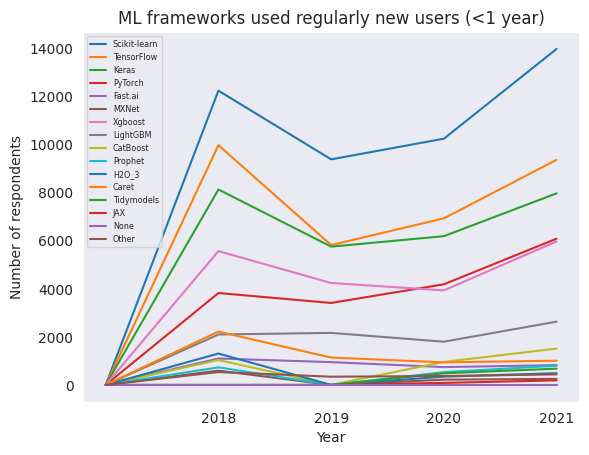

In [345]:
# select columns for each language
Scikit_learn = q16_df2['Scikit-learn']
TensorFlow = q16_df2['TensorFlow']
Keras = q16_df2['Keras']
PyTorch = q16_df2['PyTorch']
Fast_ai = q16_df2['Fast.ai']
MXNet = q16_df2['MXNet']
Xgboost = q16_df2['Xgboost']
LightGBM = q16_df2['LightGBM']
CatBoost = q16_df2['CatBoost']
Prophet = q16_df2['Prophet']
H2O_3 = q16_df2['H2O_3']
Caret = q16_df2['Caret']
Tidymodels = q16_df2['Tidymodels']
JAX = q16_df2['JAX']
None_ = q16_df2['None']
Other_ = q16_df2['Other']

# plot line chart for each language
plt.plot(q16_df2['year'], Scikit_learn, label='Scikit-learn')
plt.plot(q16_df2['year'], TensorFlow, label='TensorFlow')
plt.plot(q16_df2['year'], Keras, label='Keras')
plt.plot(q16_df2['year'], PyTorch, label='PyTorch')
plt.plot(q16_df2['year'], Fast_ai, label='Fast.ai')
plt.plot(q16_df2['year'], MXNet, label='MXNet')
plt.plot(q16_df2['year'], Xgboost, label='Xgboost')
plt.plot(q16_df2['year'], LightGBM, label='LightGBM')
plt.plot(q16_df2['year'], CatBoost, label='CatBoost')
plt.plot(q16_df2['year'], Prophet, label='Prophet')
plt.plot(q16_df2['year'], H2O_3, label='H2O_3')
plt.plot(q16_df2['year'], Caret, label='Caret')
plt.plot(q16_df2['year'], Tidymodels, label='Tidymodels')
plt.plot(q16_df2['year'], JAX, label='JAX')
plt.plot(q16_df2['year'], None_, label='None')
plt.plot(q16_df2['year'], Other_, label='Other')

# set chart title and labels
plt.title('ML frameworks used regularly new users (<1 year)')
plt.xlabel('Year')
plt.ylabel('Number of respondents')
plt.xticks(range(2018, 2022))

# show legend
legend = plt.legend(loc='upper left', fontsize='xx-small')

# show plot
plt.show()

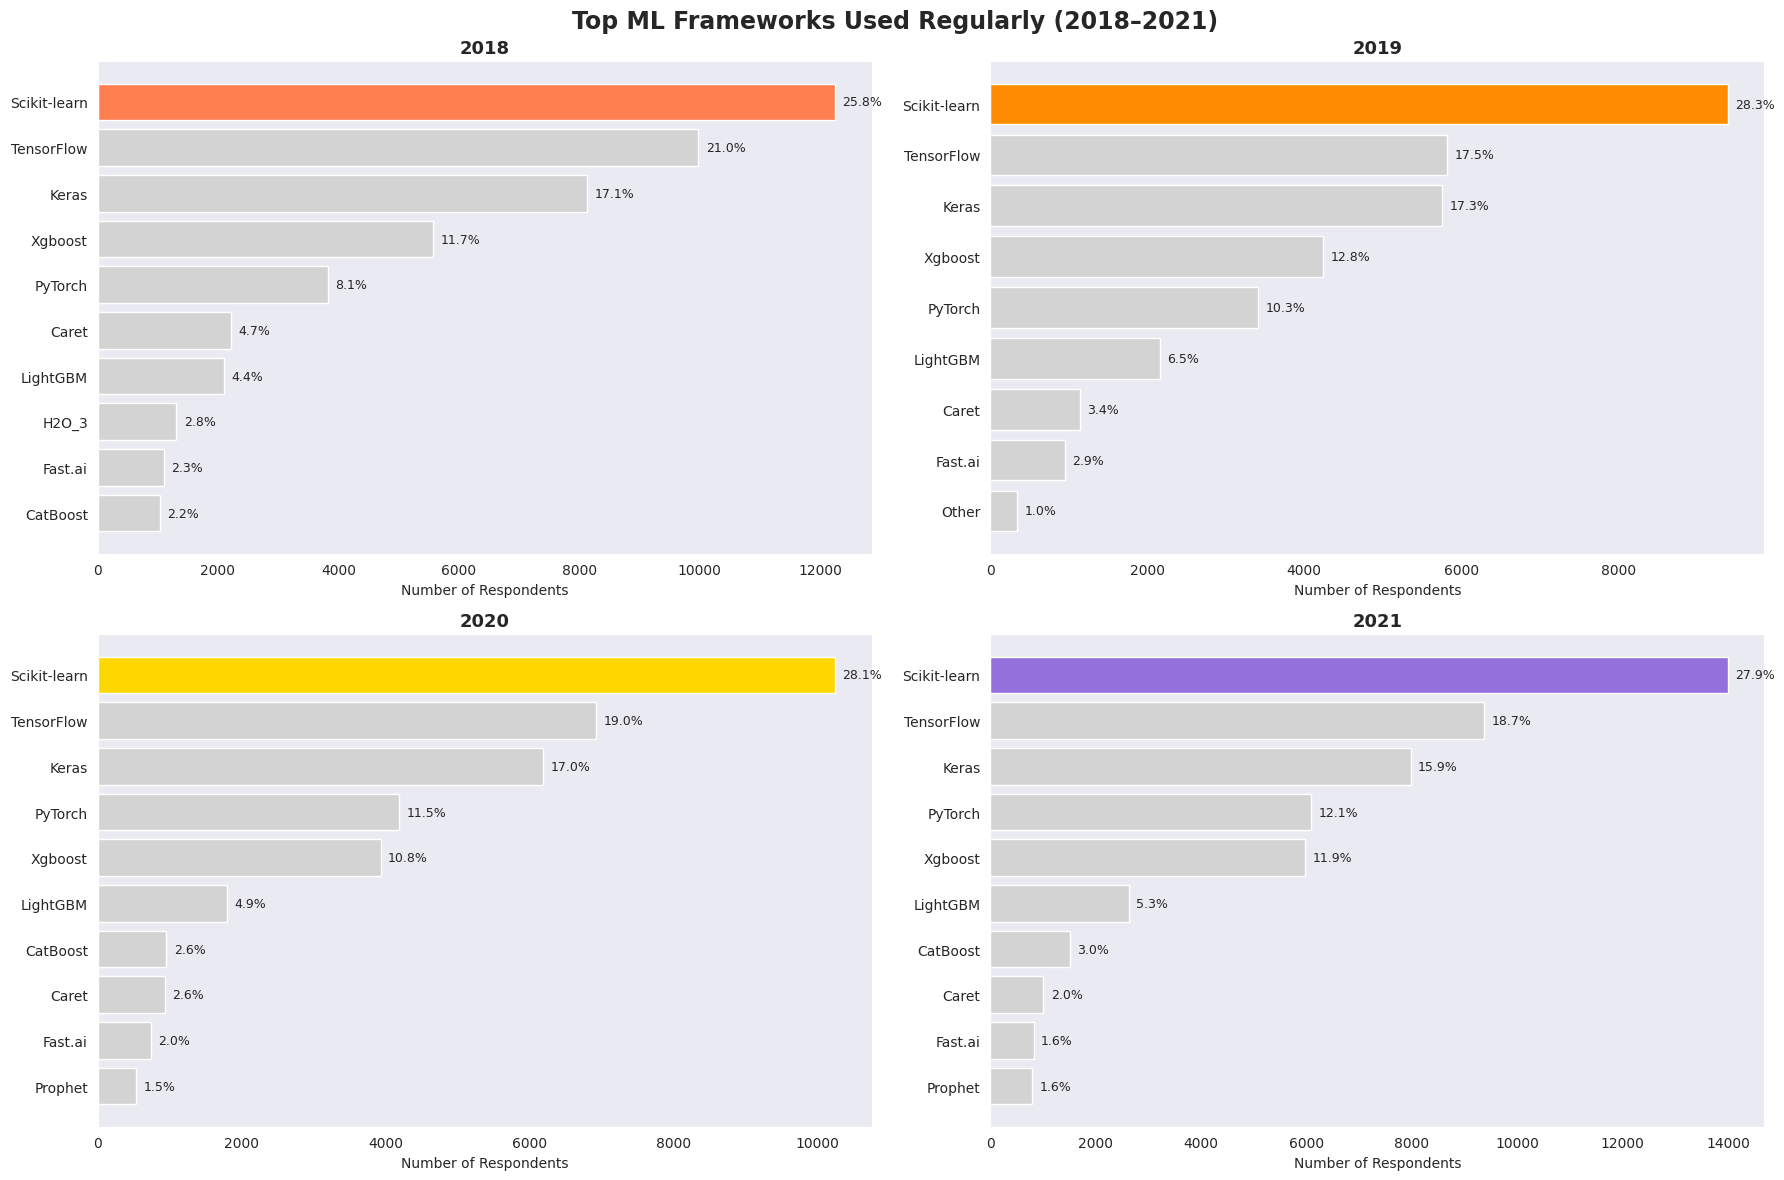

In [348]:


years = [2018, 2019, 2020, 2021]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

highlight_colors = [
    'coral',
    'darkorange',
    'gold',
    'mediumpurple'
]

for ax, year, highlight in zip(axes, years, highlight_colors):

    # Get one year's data
    temp = (
        q16_df2[q16_df2['year'] == year]
        .drop(columns='year')
        .T
    )

    temp.columns = ['Count']

    # Remove frameworks with zero responses
    temp = temp[temp['Count'] > 0]

    # Top 10 frameworks
    temp = temp.sort_values('Count').tail(10)

    # Calculate percentages
    temp['Percent'] = temp['Count'] / temp['Count'].sum() * 100

    # Highlight the most-used framework
    colors = ['lightgrey'] * len(temp)
    colors[-1] = highlight

    ax.barh(
        temp.index,
        temp['Count'],
        color=colors
    )

    # Add percentage labels
    for i, (count, pct) in enumerate(zip(temp['Count'], temp['Percent'])):
        ax.text(
            count + temp['Count'].max() * 0.01,
            i,
            f'{pct:.1f}%',
            va='center',
            fontsize=9
        )

    ax.set_title(f'{year}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of Respondents')
    ax.set_ylabel('')

plt.suptitle(
    'Top ML Frameworks Used Regularly (2018–2021)',
    fontsize=17,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [130]:
df.head()

,-_Year,Time from Start to Finish (seconds)_Duration (in seconds),Q1_What is your age (# years)?,Q2_What is your gender? - Selected Choice,Q3_In which country do you currently reside?,Q4_What is the highest level of formal education that you have attained or plan to attain within the next 2 years?,Q5_Select the title most similar to your current role (or most recent title if retired): - Selected Choice,Q6_For how many years have you been writing code and/or programming?,Q7_Part_1_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Python,Q7_Part_2_What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - R,...,"Q38_B_Part_1_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Neptune.ai","Q38_B_Part_2_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Weights & Biases","Q38_B_Part_3_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Comet.ml","Q38_B_Part_4_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Sacred + Omniboard","Q38_B_Part_5_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - TensorBoard","Q38_B_Part_6_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Guild.ai","Q38_B_Part_7_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Polyaxon","Q38_B_Part_9_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Domino Model Monitor","Q38_B_Part_11_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - None","Q38_B_OTHER_In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Other"
2,2021,910,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,784,50-54,Male,Indonesia,Master's degree,Program/Project Manager,20+ years,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021,924,22-24,Male,Pakistan,Master's degree,Software Engineer,1-3 years,Python,NaN,...,NaN,NaN,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,NaN
5,2021,575,45-49,Male,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2021,781,45-49,Male,India,Doctoral degree,Other,< 1 year,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Trends in Business Intelligence

In [349]:
df.iloc[:, [0] + list(range(154, 168))].head()

,-_Year,Q34_A_Part_1_Which of the following business intelligence tools do you use on a regular basis? (Select all that apply) - Selected Choice - Amazon QuickSight,Q34_A_Part_2_Which of the following business intelligence tools do you use on a regular basis? (Select all that apply) - Selected Choice - Microsoft Power BI,Q34_A_Part_3_Which of the following business intelligence tools do you use on a regular basis? (Select all that apply) - Selected Choice - Google Data Studio,Q34_A_Part_4_Which of the following business intelligence tools do you use on a regular basis? (Select all that apply) - Selected Choice - Looker,Q34_A_Part_5_Which of the following business intelligence tools do you use on a regular basis? (Select all that apply) - Selected Choice - Tableau,Q34_A_Part_6_Which of the following business intelligence tools do you use on a regular basis? (Select all that apply) - Selected Choice - Salesforce,Q34_A_Part_8_Which of the following business intelligence tools do you use on a regular basis? (Select all that apply) - Selected Choice - Qlik,Q34_A_Part_9_Which of the following business intelligence tools do you use on a regular basis? (Select all that apply) - Selected Choice - Domo,Q34_A_Part_10_Which of the following business intelligence tools do you use on a regular basis? (Select all that apply) - Selected Choice - TIBCO Spotfire,Q34_A_Part_11_Which of the following business intelligence tools do you use on a regular basis? (Select all that apply) - Selected Choice - Alteryx,Q34_A_Part_12_Which of the following business intelligence tools do you use on a regular basis? (Select all that apply) - Selected Choice - Sisense,Q34_A_Part_13_Which of the following business intelligence tools do you use on a regular basis? (Select all that apply) - Selected Choice - SAP Analytics Cloud,Q34_A_Part_16_Which of the following business intelligence tools do you use on a regular basis? (Select all that apply) - Selected Choice - None,Q34_A_OTHER_Which of the following business intelligence tools do you use on a regular basis? (Select all that apply) - Selected Choice - Other
2,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2021,NaN,Microsoft Power BI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [350]:
df.iloc[1:,154].unique()

array([nan, 'Amazon QuickSight'], dtype=object)

In [351]:
for i in range(154,167):
    print(df.iloc[1:,i].unique())

[nan 'Amazon QuickSight']
[nan 'Microsoft Power BI']
[nan 'Google Data Studio']
[nan 'Looker']
[nan 'Tableau']
[nan 'Salesforce']
[nan 'Qlik']
[nan 'Domo']
[nan 'TIBCO Spotfire']
[nan 'Alteryx ']
[nan 'Sisense ']
[nan 'SAP Analytics Cloud ']
[nan]


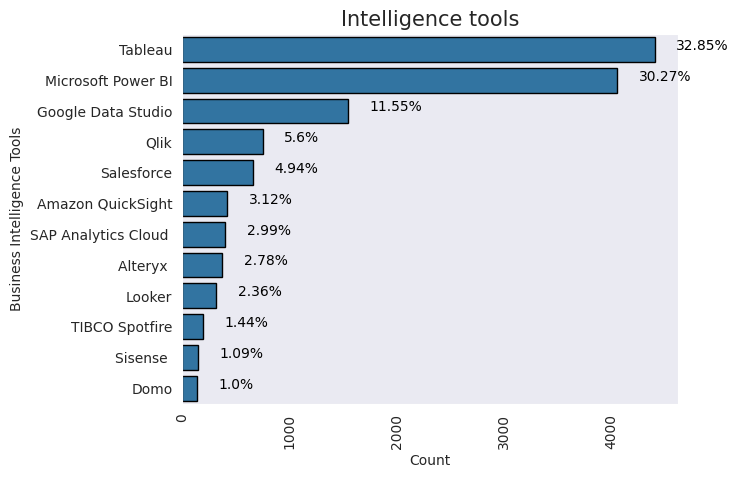

In [352]:
Intelligence_tools = {}
for i in range(154, 167):
    Intelligence_tools.update(dict(df.iloc[:, i].value_counts()))
Intelligence_tools = pd.DataFrame(Intelligence_tools.items(), columns = ["Business Intelligence Tools", "Count"])

# calculate percentage of total and sort by descending order
Intelligence_tools["Percent"] = Intelligence_tools["Count"] / Intelligence_tools["Count"].sum() * 100
Intelligence_tools = Intelligence_tools.sort_values(by="Count", ascending=False)

sns.set_style("dark")
p = sns.barplot(x="Count", y="Business Intelligence Tools", data=Intelligence_tools, edgecolor="black")
p.set_title("Intelligence tools", fontsize=15)
plt.xticks(rotation=90)
plt.xlabel("Count")
plt.ylabel("Business Intelligence Tools")
# add percentage labels to the bars
for i, v in enumerate(Intelligence_tools["Percent"].round(2)):
    p.text(Intelligence_tools.iloc[i]["Count"] + 200, i, str(v) + "%", fontsize=10, color='black')
plt.show()


## Conclusion



While there are many trends that are ongoing in the world, there is still a large gap with regards to the adoption of it in comparison to the chatter that is ongoing. Data science is definitely a hot topic as a whole with many different tooling and infrastructure provided as seen by the large variety of product offering. Even with regards to the whole hype of deep learning, traditional machine learning approaches and frameworks still remain the most popular given how deep learning approaches require more infrastructure and tooling support which correlates to the friction of adopting tooling and infrastructure. However, a caveat to note is given the demographics of the survey users where there are a large number of Student being survey users, this may skew the data given how the use case as a student differs greatly from industrial use case. Nevertheless, this still reflects to a certain degree that there are friction with regards to the adoption of these trends that are ongoing in the world.